**Predictive Analytics: Medical Insurance Cost Prediction**

1.Project Overview

1.1 Background

Dalam proyek ini, machine learning digunakan untuk memprediksi biaya asuransi kesehatan
berdasarkan karakteristik peserta yang tersedia pada dataset Medical Insurance.

1.2 Predictive Problem

Pertanyaan prediksi dalam proyek ini adalah:

> Seberapa baik biaya asuransi kesehatan (`charges`) dapat diprediksi berdasarkan
> karakteristik peserta seperti `age`, `sex`, `bmi`, `children`, `smoker`, dan `region`?

1.3 Prediction Objective

Tujuan proyek adalah membangun dan membandingkan beberapa model regresi untuk
memprediksi nilai charges.

Model yang akan dibandingkan adalah:

1. Baseline Model
2. Linear Regression
3. Random Forest Regression

1.4 Project Type

Jenis predictive analytics yang digunakan adalah:

Regression

Regression digunakan karena target `charges` merupakan nilai numerik kontinu.

1.5 Target Variable

Target variable yang akan diprediksi adalah:

charges

Target ini merepresentasikan biaya asuransi pada setiap observasi.

1.6 Unit of Analysis

Unit of analysis dalam proyek ini adalah:

**Satu peserta/pemegang polis asuransi pada satu observasi.**

 1.7 Predictors

Variabel yang digunakan sebagai potential predictors adalah:

- `age`
- `sex`
- `bmi`
- `children`
- `smoker`
- `region`

1.8 Stakeholder / Potential Value

Hasil prediksi diharapkan  dapat digunakan sebagai informasi pendukung untuk memahami
perbedaan estimasi biaya asuransi berdasarkan karakteristik peserta.

**IMPORT LIBRARY**

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

**LOAD DATASET**

In [ ]:

from google.colab import files

uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [ ]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.92
1,18,male,33.77,1,no,southeast,1725.55
2,28,male,33.00,3,no,southeast,4449.46
3,33,male,22.70,0,no,northwest,21984.47
4,32,male,28.88,0,no,northwest,3866.86


## **2. Dataset Description**

Dataset yang digunakan dalam proyek ini adalah dataset **Medical Insurance**.

Dataset sendiri berisi informasi mengenai karakteristik peserta asuransi dan biaya
asuransi yang dibayarkan.

Variabel yang tersedia terdiri dari beberapa variabel:

| Variable | Description | Type | Role |
|---|---|---|---|
| `age` | Usia peserta | Numerical | Predictor |
| `sex` | Jenis kelamin peserta | Categorical | Predictor |
| `bmi` | Body Mass Index | Numerical | Predictor |
| `children` | Jumlah anak/dependents | Numerical | Predictor |
| `smoker` | Status merokok | Categorical | Predictor |
| `region` | Wilayah tempat tinggal | Categorical | Predictor |
| `charges` | Biaya asuransi | Numerical | Target |

### Target

Target variable adalah `charges`.

### Predictor Variables

Potential predictor variables yang tersedia adalah:

- `age`
- `sex`
- `bmi`
- `children`
- `smoker`
- `region`

Dataset memiliki 1.338 observasi dan 7 variabel sehingga memenuhi persyaratan
minimum dataset proyek, yaitu minimal 500 observasi dan minimal 5 potential
predictor variables.

In [ ]:
rows, columns = df.shape

print(f"Jumlah baris: {rows}")
print(f"Jumlah kolom: {columns}")

Jumlah baris: 1338
Jumlah kolom: 7


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:

data_dictionary = pd.DataFrame({
    "Variable": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Non-Null Count": df.notnull().sum().values,
    "Unique Values": df.nunique().values
})

data_dictionary

,Variable,Data Type,Non-Null Count,Unique Values
age,age,int64,1338,47
sex,sex,object,1338,2
bmi,bmi,float64,1338,548
children,children,int64,1338,6
smoker,smoker,object,1338,2
region,region,object,1338,4
charges,charges,float64,1338,1337


In [ ]:
df.describe(include="all")

,age,sex,bmi,children,smoker,region,charges
count,1338.00,1338,1338.00,1338.00,1338,1338,1338.00
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.21,NaN,30.66,1.09,NaN,NaN,13270.42
std,14.05,NaN,6.10,1.21,NaN,NaN,12110.01
min,18.00,NaN,15.96,0.00,NaN,NaN,1121.87
25%,27.00,NaN,26.30,0.00,NaN,NaN,4740.29
50%,39.00,NaN,30.40,1.00,NaN,NaN,9382.03
75%,51.00,NaN,34.69,2.00,NaN,NaN,16639.91


In [ ]:
categorical_columns = ["sex", "smoker", "region"]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts())


sex:
sex
male      676
female    662
Name: count, dtype: int64

smoker:
smoker
no     1064
yes     274
Name: count, dtype: int64

region:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


#**3. Data Quality Assessment**

Tahap data quality assessment dilakukan untuk memahami kondisi awal dataset
sebelum preprocessing dan modeling.

Pemeriksaan meliputi:

1. Struktur dan tipe data
2. Missing values
3. Duplicate records
4. Nilai yang tidak valid
5. Distribusi target
6. Potensi data leakage
7. Outlier

Hasil pemeriksaan akan digunakan untuk menentukan langkah data preparation
pada tahap berikutnya.

In [ ]:

# Mengecek jumlah missing value
missing_values = df.isnull().sum()

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": missing_percentage
})

missing_summary

,Missing Values,Percentage (%)
age,0,0.00
sex,0,0.00
bmi,0,0.00
children,0,0.00
smoker,0,0.00
region,0,0.00
charges,0,0.00


In [ ]:
# Mengecek jumlah duplicate
duplicate_count = df.duplicated().sum()

print(f"Jumlah duplicate rows: {duplicate_count}")

duplicates = df[df.duplicated(keep=False)]

duplicates

Jumlah duplicate rows: 1


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.56
581,19,male,30.59,0,no,northwest,1639.56



Hasil pemeriksaan menunjukkan terdapat 1 duplicate row.

Duplicate akan dihapus sebelum proses
modeling untuk mencegah satu observasi dihitung lebih dari satu kali. Penghapusan duplicate dilakukan hanya pada tahap data preparation.

In [ ]:
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64



Dataset memiliki tiga kelompok tipe data:

**Numerical variables:**
- `age`
- `bmi`
- `children`
- `charges`

**Categorical variables:**
- `sex`
- `smoker`
- `region`

Variabel kategorikal perlu diubah menjadi representasi numerik sebelum digunakan
oleh model machine learning tertentu. Encoding akan dilakukan pada tahap
Data Preparation dan Feature Engineering.

In [ ]:
# Cek nilai minimum pada variabel numerik
numeric_columns = ["age", "bmi", "children", "charges"]

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.00,39.21,14.05,18.00,27.00,39.00,51.00,64.00
bmi,1338.00,30.66,6.10,15.96,26.30,30.40,34.69,53.13
children,1338.00,1.09,1.21,0.00,0.00,1.00,2.00,5.00
charges,1338.00,13270.42,12110.01,1121.87,4740.29,9382.03,16639.91,63770.43


In [ ]:

# Pemeriksaan nilai yang secara logika tidak masuk akal
print("Age <= 0:", (df["age"] <= 0).sum())
print("BMI <= 0:", (df["bmi"] <= 0).sum())
print("Children < 0:", (df["children"] < 0).sum())
print("Charges <= 0:", (df["charges"] <= 0).sum())

Age <= 0: 0
BMI <= 0: 0
Children < 0: 0
Charges <= 0: 0


Pemeriksaan nilai tidak valid dilakukan berdasarkan batas logis masing-masing
variabel.

Pemeriksaan meliputi:

- `age` tidak boleh bernilai 0 atau negatif.
- `bmi` tidak boleh bernilai 0 atau negatif.
- `children` tidak boleh bernilai negatif.
- `charges` tidak boleh bernilai 0 atau negatif dalam konteks biaya asuransi.

Hasil pemeriksaan akan digunakan untuk menentukan apakah terdapat nilai yang
perlu ditangani pada tahap data preparation.

In [ ]:
# Statistik target
df["charges"].describe()

,charges
count,1338.00
mean,13270.42
std,12110.01
min,1121.87
25%,4740.29
50%,9382.03
75%,16639.91
max,63770.43


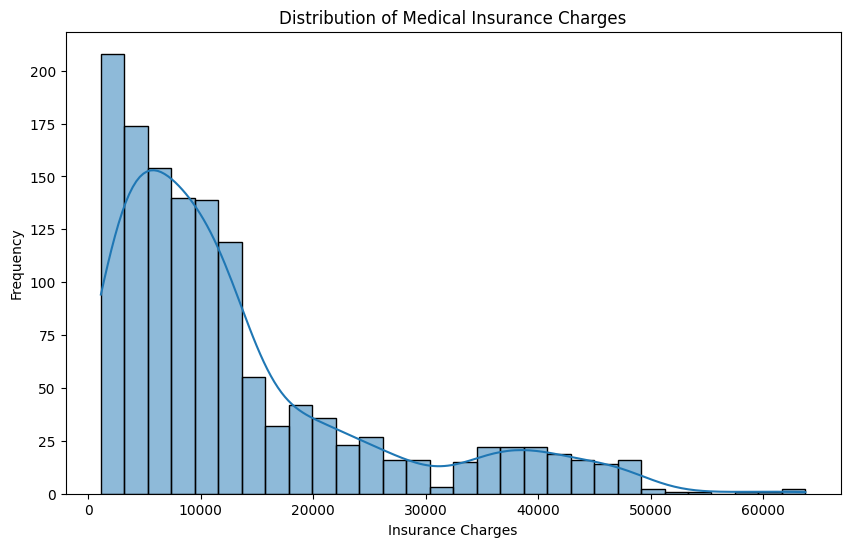

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="charges",
    bins=30,
    kde=True
)

plt.title("Distribution of Medical Insurance Charges")
plt.xlabel("Insurance Charges")
plt.ylabel("Frequency")

plt.show()

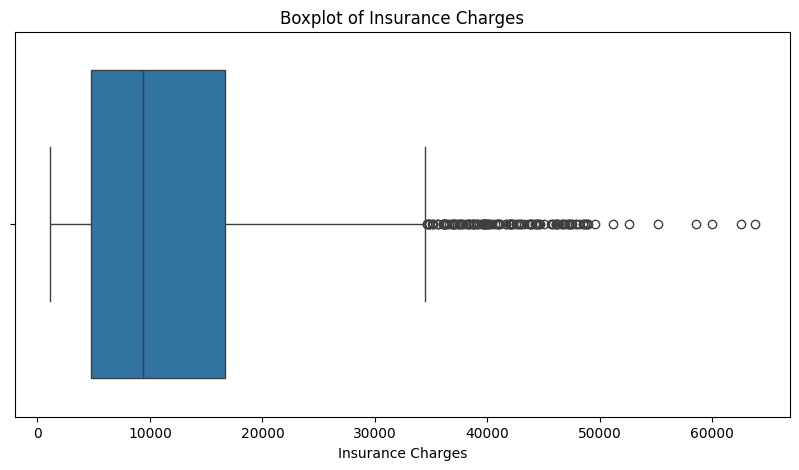

In [ ]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["charges"])

plt.title("Boxplot of Insurance Charges")
plt.xlabel("Insurance Charges")

plt.show()

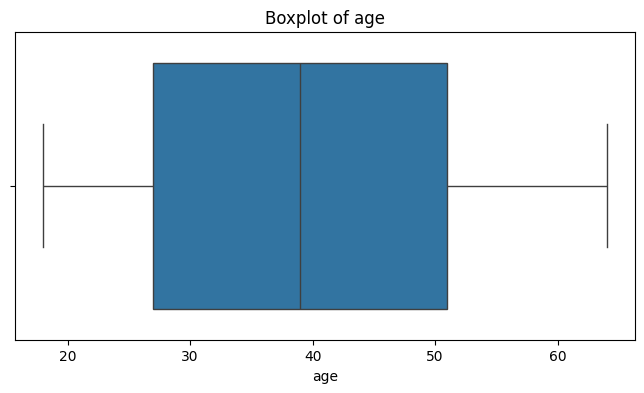

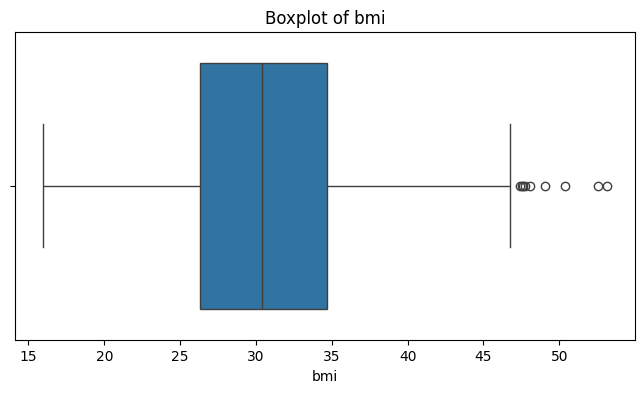

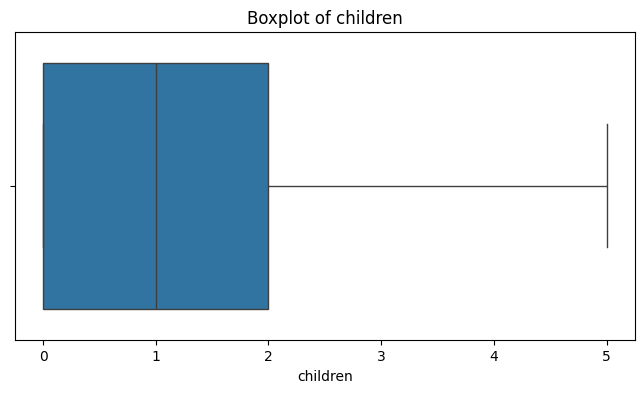

In [ ]:
numeric_predictors = ["age", "bmi", "children"]

for column in numeric_predictors:
    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df[column])

    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)

    plt.show()

In [ ]:
# Menampilkan seluruh kolom
print("Columns in dataset:")
print(df.columns.tolist())

Columns in dataset:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


In [ ]:
quality_summary = pd.DataFrame({
    "Check": [
        "Baris",
        "Kolom",
        "Missing values",
        "Duplicate rows",
        "Target variable",
        "Numerical variables",
        "Categorical variables"
    ],
    "Result": [
        len(df),
        len(df.columns),
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        "charges",
        "age, bmi, children, charges",
        "sex, smoker, region"
    ]
})

quality_summary

,Check,Result
0,Baris,1338
1,Kolom,7
2,Missing values,0
3,Duplicate rows,1
4,Target variable,charges
5,Numerical variables,"age, bmi, children, charges"
6,Categorical variables,"sex, smoker, region"


Berdasarkan pemeriksaan awal terhadap dataset:

- Dataset memiliki 1.338 Baris dan 7 Kolom
- `charges` digunakan sebagai target variable.
- Terdapat 6 potential predictor variables.
- Tidak ditemukan missing value.
- Terdapat 1 duplicate row.
- Dataset memiliki variabel numerik dan kategorikal.
- Variabel kategorikal membutuhkan encoding sebelum modeling.
- Distribusi `charges` perlu diperhatikan karena terdapat kemungkinan nilai
  ekstrem yang akan dianalisis lebih lanjut.
- Potensi data leakage akan dicegah dengan tidak menggunakan `charges` sebagai predictor dan dengan melakukan preprocessing berdasarkan training data.

#4. Data Preparation

Tahap data preparation dilakukan untuk mempersiapkan dataset sebelum digunakan
dalam proses pemodelan.

Tahapan yang dilakukan adalah:

1. Menghapus duplicate record yang teridentifikasi.
2. Memisahkan predictor (`X`) dan target (`y`).
3. Membagi data menjadi training set dan testing set.
4. Menentukan variabel numerik dan kategorikal.
5. Melakukan encoding terhadap variabel kategorikal.
6. Melakukan scaling terhadap variabel numerik jika diperlukan.
7. Memastikan preprocessing tidak menyebabkan data leakage.

Preprocessing akan dilakukan menggunakan `ColumnTransformer` dan `Pipeline`.

In [ ]:
# Membuat salinan dataset
df_clean = df.copy()

print("Ukuran dataset sebelum cleaning:", df_clean.shape)

Ukuran dataset sebelum cleaning: (1338, 7)


In [ ]:
# Mengecek duplicate sebelum dihapus
print("Duplicate sebelum cleaning:", df_clean.duplicated().sum())

# Menghapus duplicate
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("Duplicate setelah cleaning:", df_clean.duplicated().sum())
print("Ukuran dataset setelah cleaning:", df_clean.shape)

Duplicate sebelum cleaning: 1
Duplicate setelah cleaning: 0
Ukuran dataset setelah cleaning: (1337, 7)


In [ ]:
# Menentukan target
target = "charges"

# Predictor variables
features = [
    "age",
    "sex",
    "bmi",
    "children",
    "smoker",
    "region"
]

# Membuat X dan y
X = df_clean[features]
y = df_clean[target]

print("Jumlah predictor:", X.shape[1])
print("Jumlah observasi:", X.shape[0])
print("Target:", target)

Jumlah predictor: 6
Jumlah observasi: 1337
Target: charges


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data :", X_train.shape)
print("Testing data  :", X_test.shape)

Training data : (1069, 6)
Testing data  : (268, 6)


Dataset dibagi menjadi:

- 80% training data
- 20% testing data

Training data digunakan untuk membangun model, sedangkan testing data digunakan
untuk mengevaluasi kemampuan model terhadap data yang tidak digunakan selama
training.

`random_state=42` digunakan agar pembagian data dapat direproduksi.

In [ ]:
# Numerical features
numeric_features = [
    "age",
    "bmi",
    "children"
]

# Categorical features
categorical_features = [
    "sex",
    "smoker",
    "region"
]

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'bmi', 'children']

Categorical features:
['sex', 'smoker', 'region']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Pipeline untuk numerical features
numeric_transformer = StandardScaler()

# Pipeline untuk categorical features
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    drop="first"
)

# Menggabungkan preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor berhasil dibuat.")

Preprocessor berhasil dibuat.


In [ ]:
# Fit hanya menggunakan training data
preprocessor.fit(X_train)

# Transform training dan testing
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Shape X_train setelah preprocessing:", X_train_processed.shape)
print("Shape X_test setelah preprocessing:", X_test_processed.shape)

Shape X_train setelah preprocessing: (1069, 8)
Shape X_test setelah preprocessing: (268, 8)


In [ ]:

# Mendapatkan nama fitur setelah preprocessing
feature_names = preprocessor.get_feature_names_out()

print("Jumlah fitur setelah preprocessing:", len(feature_names))

print("\nFeature names:")
for feature in feature_names:
    print(feature)

Jumlah fitur setelah preprocessing: 8

Feature names:
num__age
num__bmi
num__children
cat__sex_male
cat__smoker_yes
cat__region_northwest
cat__region_southeast
cat__region_southwest


In [ ]:
# Mengubah hasil preprocessing menjadi DataFrame
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

X_train_processed_df.head()

,num__age,num__bmi,num__children,cat__sex_male,cat__smoker_yes,cat__region_northwest,cat__region_southeast,cat__region_southwest
1113,-1.16,-1.00,-0.91,1.00,0.00,0.00,0.00,0.00
967,-1.30,-0.79,0.77,1.00,0.00,0.00,0.00,0.00
598,0.91,1.15,0.77,0.00,0.00,1.00,0.00,0.00
170,1.70,1.81,-0.91,1.00,0.00,0.00,1.00,0.00
275,0.56,-0.65,0.77,0.00,0.00,0.00,0.00,0.00


In [ ]:
X_train_processed_df.describe().T

,count,mean,std,min,25%,50%,75%,max
num__age,1069.00,0.00,1.00,-1.52,-0.87,-0.01,0.84,1.77
num__bmi,1069.00,0.00,1.00,-2.41,-0.72,-0.06,0.64,3.73
num__children,1069.00,0.00,1.00,-0.91,-0.91,-0.07,0.77,3.28
cat__sex_male,1069.00,0.51,0.50,0.00,0.00,1.00,1.00,1.00
cat__smoker_yes,1069.00,0.20,0.40,0.00,0.00,0.00,0.00,1.00
cat__region_northwest,1069.00,0.25,0.43,0.00,0.00,0.00,0.00,1.00
cat__region_southeast,1069.00,0.27,0.44,0.00,0.00,0.00,1.00,1.00
cat__region_southwest,1069.00,0.25,0.43,0.00,0.00,0.00,0.00,1.00


In [ ]:
print("FINAL CHECK")

print("Original dataset :", df.shape)
print("Clean dataset    :", df_clean.shape)

print("\nX_train :", X_train.shape)
print("X_test  :", X_test.shape)

print("\ny_train :", y_train.shape)
print("y_test  :", y_test.shape)

print("\nProcessed X_train :", X_train_processed.shape)
print("Processed X_test  :", X_test_processed.shape)

FINAL CHECK
Original dataset : (1338, 7)
Clean dataset    : (1337, 7)

X_train : (1069, 6)
X_test  : (268, 6)

y_train : (1069,)
y_test  : (268,)

Processed X_train : (1069, 8)
Processed X_test  : (268, 8)


Tahap data preparation menghasilkan beberapa perubahan penting:

1. Satu duplicate row telah dihapus.
2. Target `charges` dipisahkan dari predictor variables.
3. Dataset dibagi menjadi training data sebesar 80% dan testing data sebesar 20%.
4. Variabel numerik terdiri dari `age`, `bmi`, dan `children`.
5. Variabel kategorikal terdiri dari `sex`, `smoker`, dan `region`.
6. Variabel kategorikal diubah menggunakan One-Hot Encoding.
7. Variabel numerik dilakukan standardisasi menggunakan StandardScaler.
8. Preprocessing hanya di-fit menggunakan training data untuk mencegah data leakage.
9. Data hasil preprocessing siap digunakan untuk membangun model regression.

#5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) dilakukan untuk memahami karakteristik
data sebelum membangun model prediksi.

Analisis difokuskan pada:

1. Distribusi variabel target `charges`.
2. Distribusi variabel numerik.
3. Distribusi variabel kategorikal.
4. Hubungan antara variabel numerik dengan `charges`.
5. Perbedaan `charges` berdasarkan variabel kategorikal.
6. Korelasi antar variabel numerik.
7. Identifikasi pola yang dapat membantu proses pemodelan.

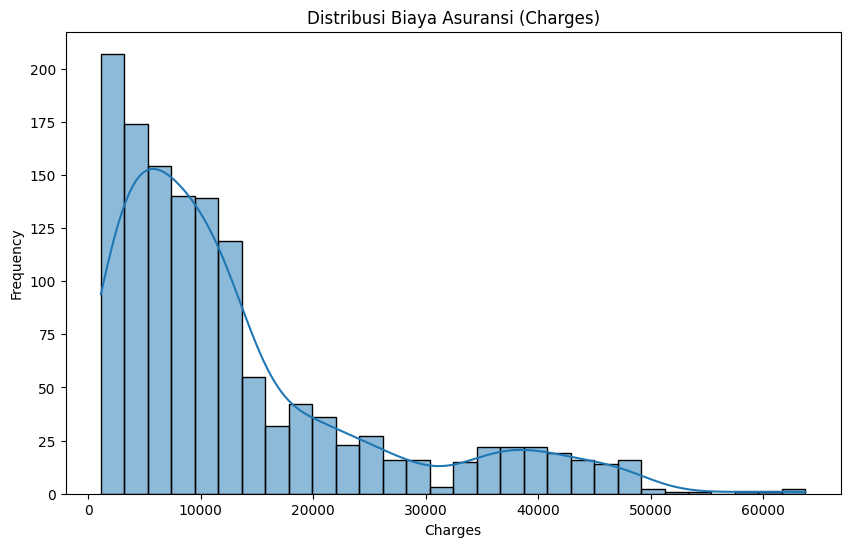

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(
    df_clean["charges"],
    bins=30,
    kde=True
)

plt.title("Distribusi Biaya Asuransi (Charges)")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

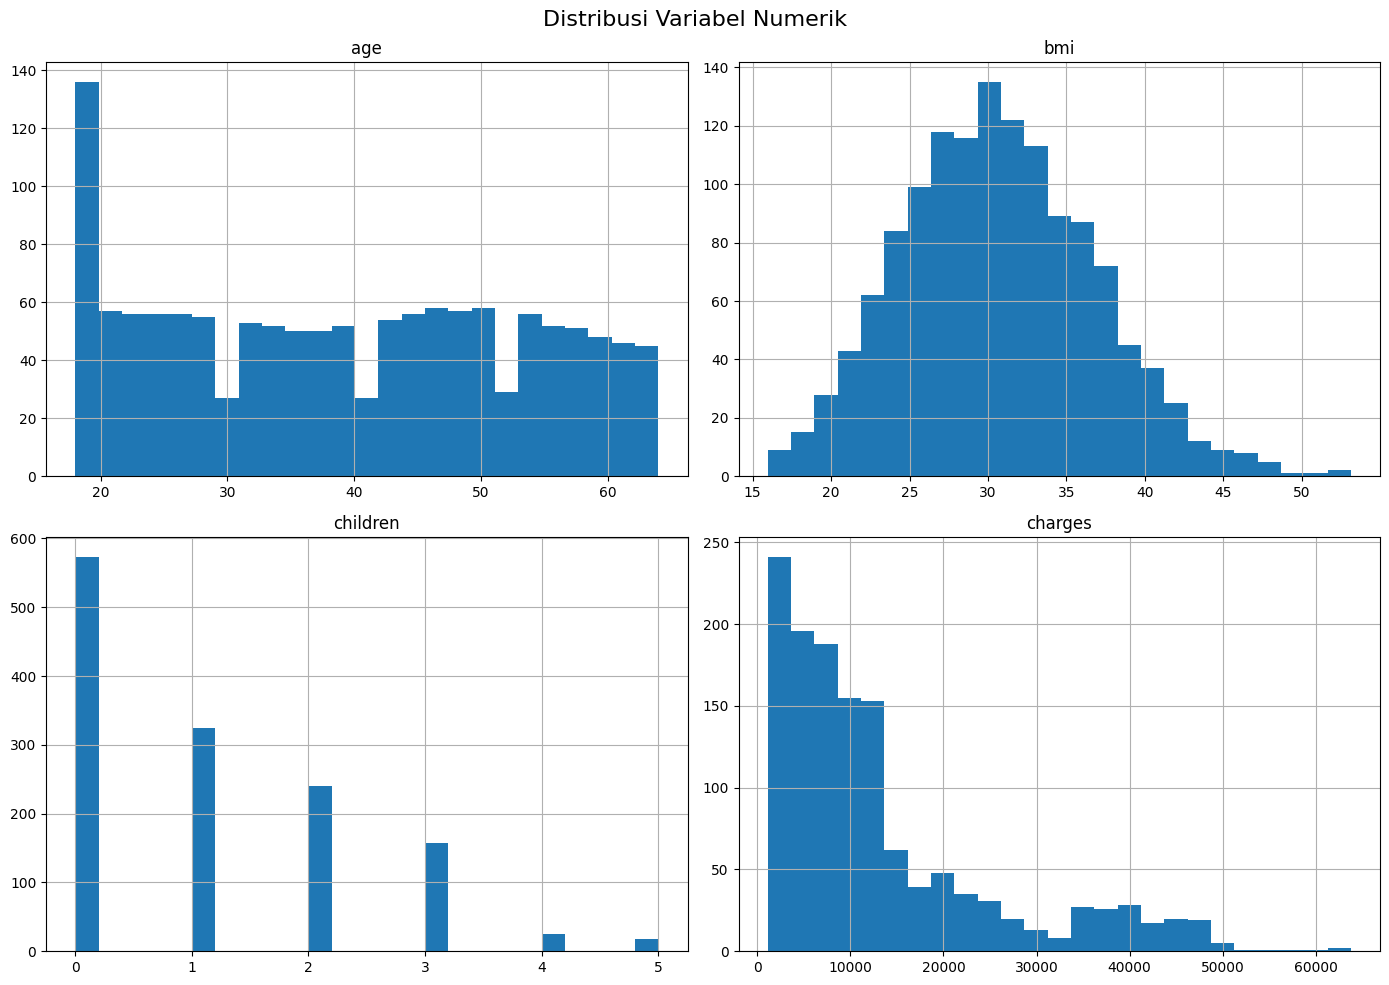

In [ ]:
numeric_cols = [
    "age",
    "bmi",
    "children",
    "charges"
]

df_clean[numeric_cols].hist(
    figsize=(14, 10),
    bins=25
)

plt.suptitle(
    "Distribusi Variabel Numerik",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [ ]:
df_clean[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,1337.00,39.22,14.04,18.00,27.00,39.00,51.00,64.00
bmi,1337.00,30.66,6.10,15.96,26.29,30.40,34.70,53.13
children,1337.00,1.10,1.21,0.00,0.00,1.00,2.00,5.00
charges,1337.00,13279.12,12110.36,1121.87,4746.34,9386.16,16657.72,63770.43


Analisis distribusi menunjukkan karakteristik dasar dari variabel numerik.

`age` menggambarkan usia peserta, `bmi` menggambarkan indeks massa tubuh,
`children` menunjukkan jumlah anak/dependen, sedangkan `charges`
merupakan target biaya asuransi.

Statistik deskriptif digunakan untuk melihat nilai minimum, maksimum,
rata-rata, median, dan penyebaran setiap variabel.

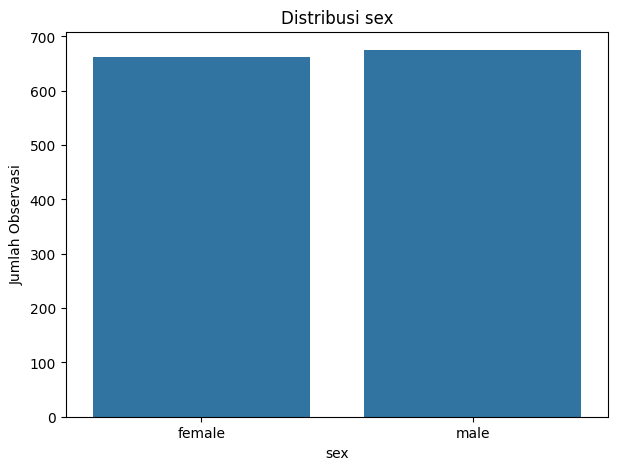

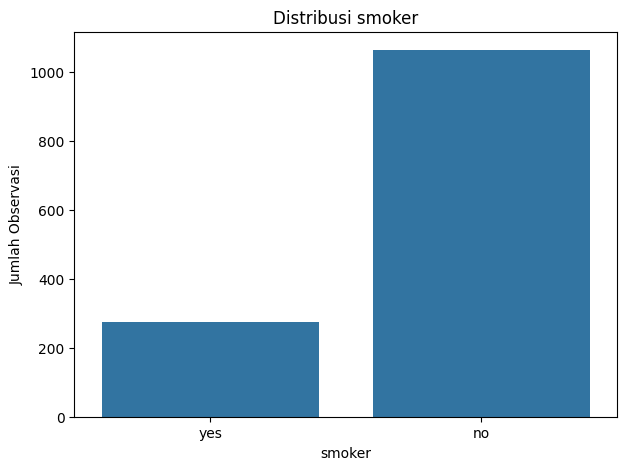

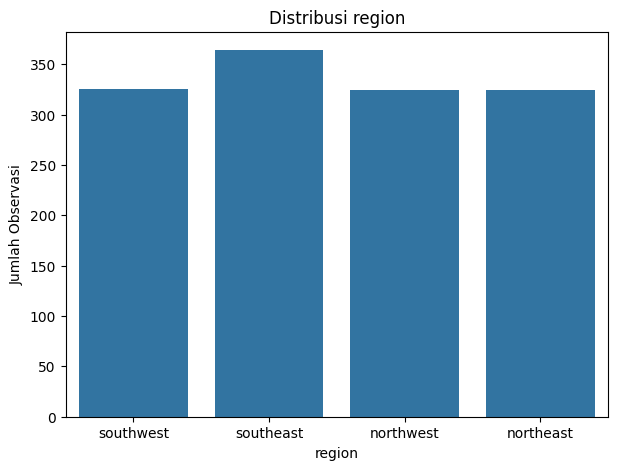

In [ ]:
categorical_cols = [
    "sex",
    "smoker",
    "region"
]

for col in categorical_cols:
    plt.figure(figsize=(7, 5))

    sns.countplot(
        data=df_clean,
        x=col
    )

    plt.title(f"Distribusi {col}")
    plt.xlabel(col)
    plt.ylabel("Jumlah Observasi")
    plt.show()

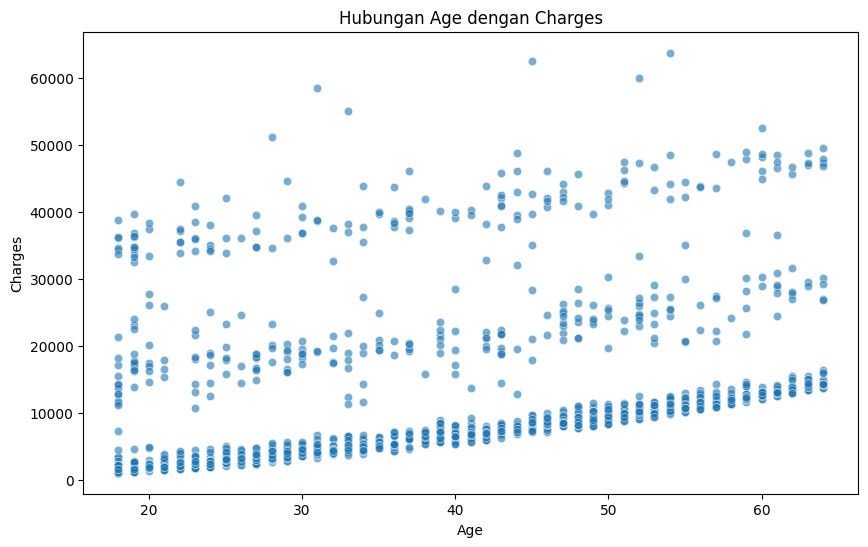

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="age",
    y="charges",
    alpha=0.6
)

plt.title("Hubungan Age dengan Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

Scatter plot digunakan untuk melihat pola hubungan antara usia peserta
dengan biaya asuransi.

Jika terdapat kecenderungan nilai `charges` meningkat pada kelompok usia
yang lebih tinggi, maka `age` dapat menjadi salah satu variabel yang
berguna dalam prediksi.

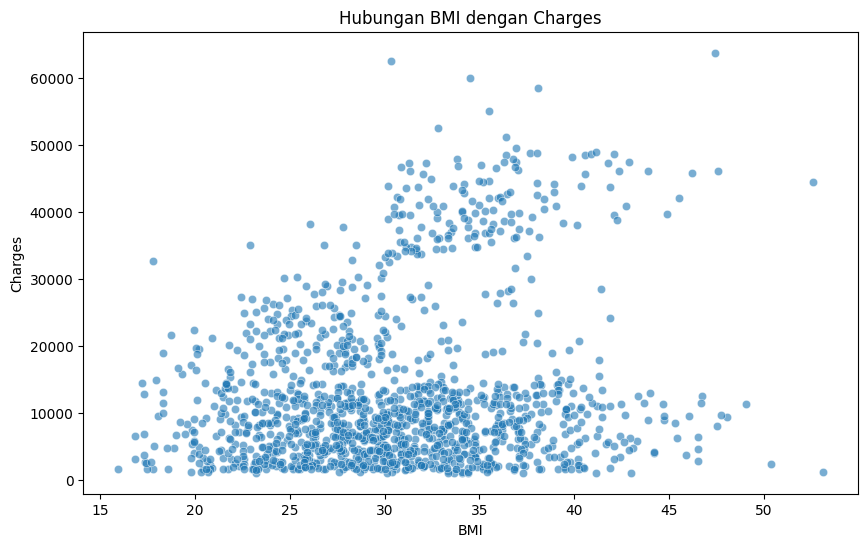

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="bmi",
    y="charges",
    alpha=0.6
)

plt.title("Hubungan BMI dengan Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

Scatter plot digunakan untuk melihat apakah terdapat pola antara BMI
dan biaya asuransi.

Pola yang terlihat pada grafik akan digunakan sebagai informasi awal
mengenai potensi kontribusi `bmi` terhadap prediksi `charges`.

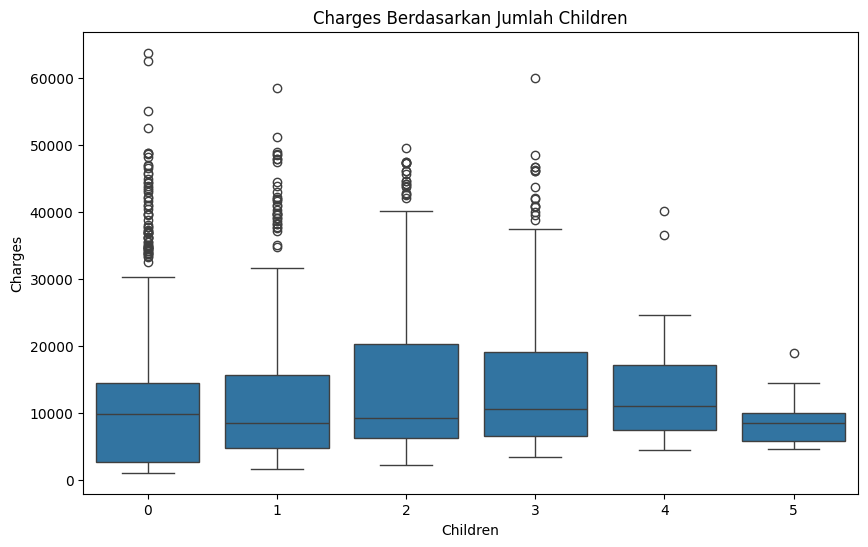

In [ ]:

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="children",
    y="charges"
)

plt.title("Charges Berdasarkan Jumlah Children")
plt.xlabel("Children")
plt.ylabel("Charges")
plt.show()

Boxplot digunakan untuk membandingkan distribusi biaya asuransi pada
masing-masing jumlah `children`.

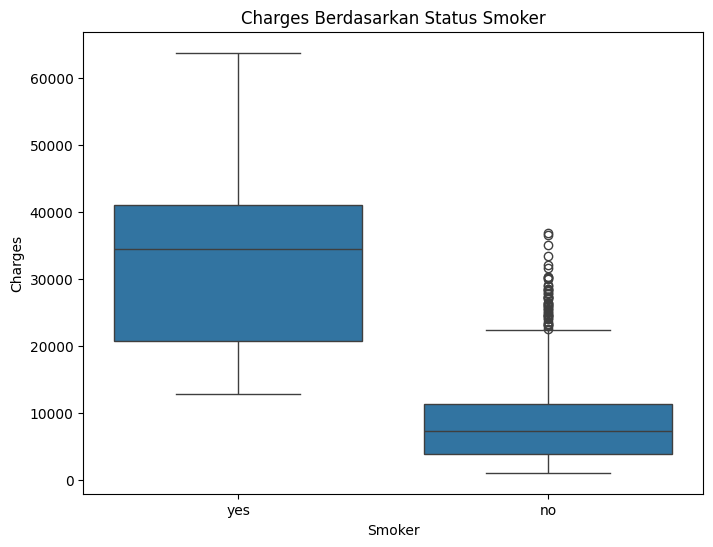

In [ ]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df_clean,
    x="smoker",
    y="charges"
)

plt.title("Charges Berdasarkan Status Smoker")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()

In [ ]:
df_clean.groupby("smoker")["charges"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

,count,mean,median,std,min,max
smoker,,,,,,
no,1063,8440.66,7345.73,5992.97,1121.87,36910.61
yes,274,32050.23,34456.35,11541.55,12829.46,63770.43


Boxplot membandingkan distribusi `charges` antara peserta yang memiliki
status `smoker` berbeda.

Perbedaan posisi median, rentang interkuartil, dan penyebaran biaya
dapat memberikan indikasi bahwa `smoker` merupakan variabel yang relevan
untuk prediksi.

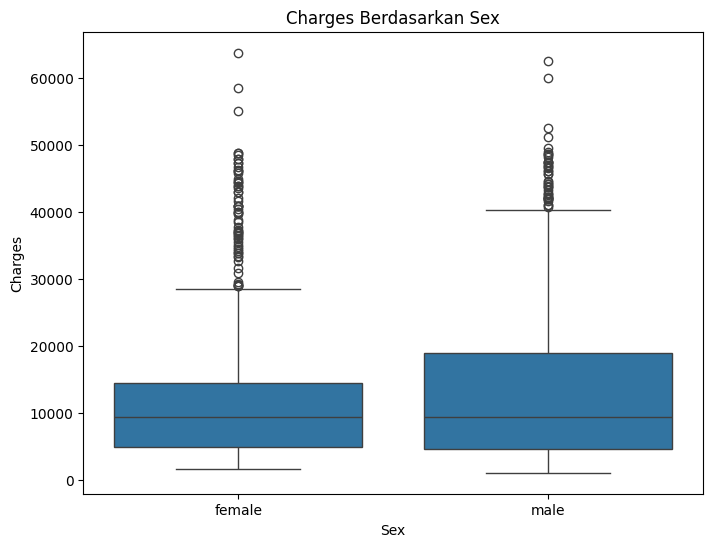

In [ ]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df_clean,
    x="sex",
    y="charges"
)

plt.title("Charges Berdasarkan Sex")
plt.xlabel("Sex")
plt.ylabel("Charges")
plt.show()

In [ ]:
df_clean.groupby("sex")["charges"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

,count,mean,median,std,min,max
sex,,,,,,
female,662,12569.58,9412.96,11128.70,1607.51,63770.43
male,675,13975.00,9377.90,12971.96,1121.87,62592.87


Perbandingan berdasarkan `sex` digunakan untuk melihat apakah distribusi
biaya asuransi berbeda antar kategori.

Perbedaan statistik deskriptif tidak secara otomatis berarti bahwa
`sex` menyebabkan perubahan biaya asuransi.

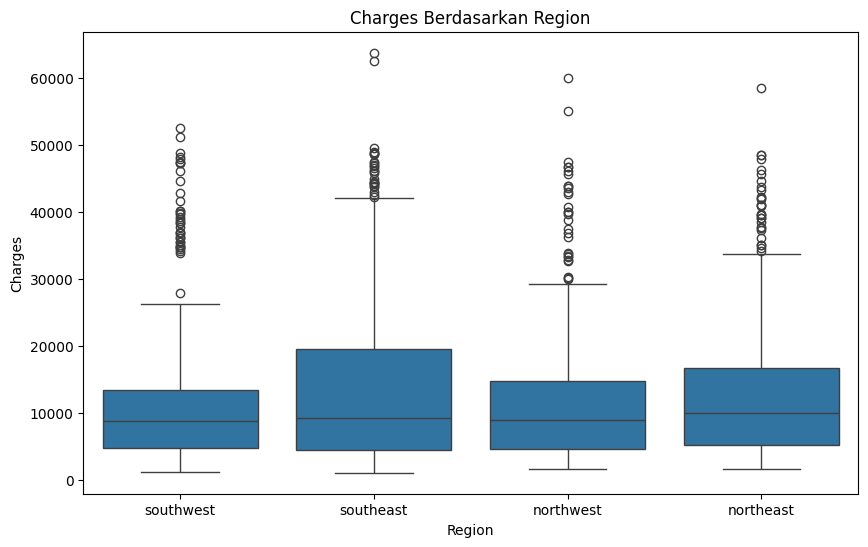

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="region",
    y="charges"
)

plt.title("Charges Berdasarkan Region")
plt.xlabel("Region")
plt.ylabel("Charges")
plt.xticks(rotation=0)
plt.show()

In [ ]:
df_clean.groupby("region")["charges"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).sort_values("mean", ascending=False)

,count,mean,median,std,min,max
region,,,,,,
southeast,364,14735.41,9294.13,13971.10,1121.87,63770.43
northeast,324,13406.38,10057.65,11255.80,1694.80,58571.07
northwest,324,12450.84,8976.98,11073.13,1621.34,60021.40
southwest,325,12346.94,8798.59,11557.18,1241.57,52590.83


Perbandingan berdasarkan `region` digunakan untuk mengetahui apakah
distribusi biaya asuransi memiliki perbedaan antar wilayah.

Variabel `region` tetap dipertahankan sebagai kandidat predictor dan
akan dikonversi menjadi variabel numerik melalui One-Hot Encoding pada
tahap pemodelan.

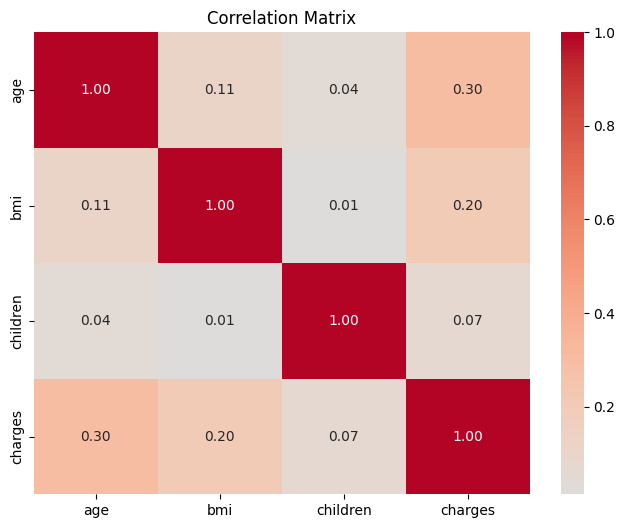

In [ ]:
correlation_matrix = df_clean[
    ["age", "bmi", "children", "charges"]
].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

Correlation matrix digunakan untuk melihat hubungan linear antar
variabel numerik.

Perhatian utama diberikan pada korelasi setiap predictor numerik
terhadap `charges`.

Korelasi digunakan sebagai informasi eksploratif dan tidak dapat
digunakan untuk menyimpulkan hubungan sebab-akibat.

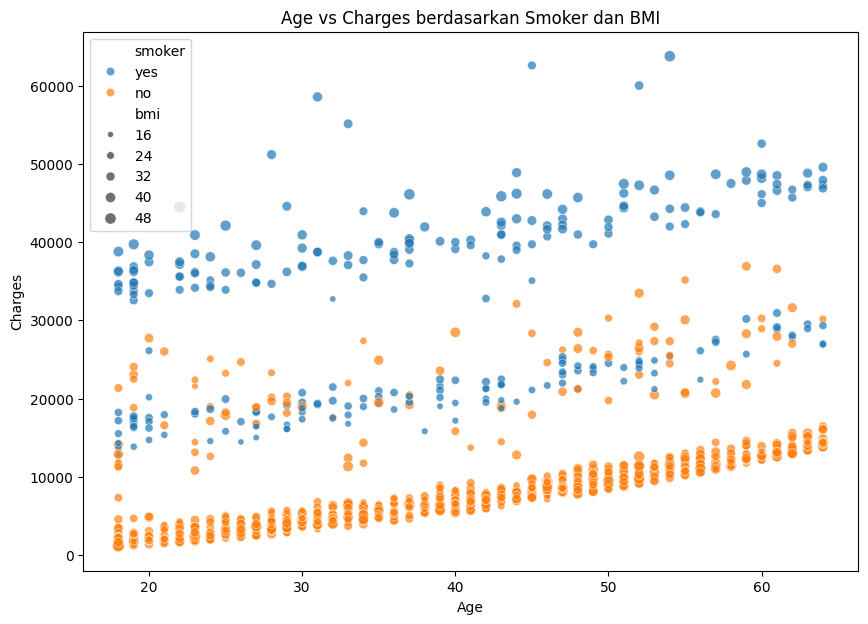

In [ ]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_clean,
    x="age",
    y="charges",
    hue="smoker",
    size="bmi",
    alpha=0.7
)

plt.title("Age vs Charges berdasarkan Smoker dan BMI")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

In [ ]:
eda_summary = pd.DataFrame({
    "Variable": [
        "age",
        "bmi",
        "children",
        "sex",
        "smoker",
        "region"
    ],
    "Type": [
        "Numerical",
        "Numerical",
        "Numerical",
        "Categorical",
        "Categorical",
        "Categorical"
    ],
    "Role": [
        "Predictor",
        "Predictor",
        "Predictor",
        "Predictor",
        "Predictor",
        "Predictor"
    ],
    "EDA Purpose": [
        "Analyze relationship with charges",
        "Analyze relationship with charges",
        "Compare charges across children groups",
        "Compare charges across sex categories",
        "Compare charges across smoker categories",
        "Compare charges across regions"
    ]
})

eda_summary

,Variable,Type,Role,EDA Purpose
0,age,Numerical,Predictor,Analyze relationship with charges
1,bmi,Numerical,Predictor,Analyze relationship with charges
2,children,Numerical,Predictor,Compare charges across children groups
3,sex,Categorical,Predictor,Compare charges across sex categories
4,smoker,Categorical,Predictor,Compare charges across smoker categories
5,region,Categorical,Predictor,Compare charges across regions


Berdasarkan hasil EDA, dataset memiliki kombinasi variabel numerik dan
kategorikal yang dapat digunakan untuk memprediksi `charges`.

Variabel numerik `age`, `bmi`, dan `children` menunjukkan karakteristik
distribusi yang berbeda dan memiliki pola hubungan tertentu terhadap
target `charges`.

Sementara itu, variabel kategorikal `sex`, `smoker`, dan `region`
menunjukkan perbedaan distribusi `charges` antar kategori.

Secara khusus, visualisasi `charges` berdasarkan `smoker` menunjukkan
perbedaan distribusi.
Hubungan `age` dan `bmi` terhadap `charges` juga menunjukkan pola yang hampir sama.
Korelasi antar variabel numerik digunakan sebagai informasi eksploratif
untuk memahami hubungan linear dalam
 data.

#6. Feature Engineering

Feature engineering dilakukan untuk mempersiapkan variabel agar dapat
digunakan secara efektif oleh algoritma machine learning.

Pada dataset Medical Insurance, feature engineering difokuskan pada:

1. Pemisahan predictor numerik dan kategorikal.
2. Standardisasi variabel numerik.
3. One-Hot Encoding variabel kategorikal.
4. Pengelolaan kategori yang mungkin tidak ditemukan pada data training.
5. Integrasi seluruh preprocessing ke dalam Pipeline.

In [ ]:
# Menentukan target dan predictor

target = "charges"

features = [
    "age",
    "sex",
    "bmi",
    "children",
    "smoker",
    "region"
]

X = df_clean[features]
y = df_clean[target]

print("Features:")
print(features)

print("\nTarget:")
print(target)

print("\nShape X:", X.shape)
print("Shape y:", y.shape)

Features:
['age', 'sex', 'bmi', 'children', 'smoker', 'region']

Target:
charges

Shape X: (1337, 6)
Shape y: (1337,)


In [ ]:

numeric_features = [
    "age",
    "bmi",
    "children"
]

categorical_features = [
    "sex",
    "smoker",
    "region"
]

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'bmi', 'children']

Categorical features:
['sex', 'smoker', 'region']


In [ ]:

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Preprocessing untuk variabel numerik
numeric_transformer = StandardScaler()

# Preprocessing untuk variabel kategorikal
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    drop="first"
)

# Menggabungkan preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Preprocessing untuk variabel numerik
numeric_transformer = StandardScaler()

# Preprocessing untuk variabel kategorikal
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    drop="first"
)

# Menggabungkan preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)


print(preprocessor)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['age', 'bmi', 'children']),
                                ('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['sex', 'smoker', 'region'])])


`StandardScaler` digunakan untuk melakukan standardisasi pada variabel
numerik.

`OneHotEncoder` digunakan untuk mengubah variabel kategorikal menjadi
fitur numerik.

Parameter `handle_unknown="ignore"` digunakan agar kategori yang muncul
pada data evaluasi tetapi tidak ditemukan ketika preprocessing dilatih
tidak menyebabkan error.

Parameter `drop="first"` digunakan untuk menghilangkan satu kategori
referensi pada setiap variabel kategorikal sehingga jumlah fitur tidak
berlebihan.

`ColumnTransformer` kemudian menggabungkan kedua proses tersebut menjadi
satu preprocessing transformer.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

linear_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', LinearRegression())])

In [ ]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model',
                 RandomForestRegressor(n_estimators=300, n_jobs=-1,
                                       random_state=42))])

In [ ]:
# Fit preprocessing hanya menggunakan data training
preprocessor.fit(X_train)

feature_names = preprocessor.get_feature_names_out()

print("Jumlah fitur setelah preprocessing:")
print(len(feature_names))

print("\nNama fitur:")
for feature in feature_names:
    print(feature)

Jumlah fitur setelah preprocessing:
8

Nama fitur:
num__age
num__bmi
num__children
cat__sex_male
cat__smoker_yes
cat__region_northwest
cat__region_southeast
cat__region_southwest


In [ ]:
X_train_processed = preprocessor.transform(X_train)

print("Shape data training sebelum preprocessing:")
print(X_train.shape)

print("\nShape data training setelah preprocessing:")
print(X_train_processed.shape)

Shape data training sebelum preprocessing:
(1069, 6)

Shape data training setelah preprocessing:
(1069, 8)


In [ ]:
X_test_processed = preprocessor.transform(X_test)

print("Shape data testing sebelum preprocessing:")
print(X_test.shape)

print("\nShape data testing setelah preprocessing:")
print(X_test_processed.shape)

Shape data testing sebelum preprocessing:
(268, 6)

Shape data testing setelah preprocessing:
(268, 8)


In [ ]:
X_train_processed
X_test_processed

array([[ 0.70051832, -1.3267337 , -0.90790804, ...,  0.        ,
         0.        ,  0.        ],
       [-0.72886531, -0.8167329 ,  2.44171645, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.84345668,  0.96620343,  1.60431032, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [-1.22914958,  0.6678075 ,  0.7669042 , ...,  0.        ,
         0.        ,  0.        ],
       [ 1.5581485 ,  0.95215155, -0.07050192, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.55757996, -1.02833777, -0.90790804, ...,  0.        ,
         0.        ,  0.        ]])

In [ ]:
linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', LinearRegression())])

In [ ]:
random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model',
                 RandomForestRegressor(n_estimators=300, n_jobs=-1,
                                       random_state=42))])

Feature engineering pada penelitian ini difokuskan pada transformasi
yang diperlukan agar seluruh predictor dapat digunakan oleh algoritma
machine learning.

Variabel numerik `age`, `bmi`, dan `children` diproses menggunakan
standardisasi.

Variabel kategorikal `sex`, `smoker`, dan `region` diproses menggunakan
One-Hot Encoding.

Seluruh preprocessing kemudian diintegrasikan dengan model menggunakan
Pipeline.

Tidak dilakukan penghapusan predictor maupun pembentukan banyak fitur
turunan karena seluruh predictor awal memiliki relevansi terhadap tujuan
prediksi dan jumlah fitur relatif kecil.

Pendekatan ini mempertahankan interpretasi fitur sekaligus menyediakan
workflow preprocessing yang konsisten untuk proses training dan
evaluasi model.

#7. Baseline Model

Baseline model digunakan sebagai model pembanding sederhana sebelum
membangun model machine learning.

Pada penelitian ini digunakan `DummyRegressor` dengan strategi `mean`.
Model baseline akan selalu memprediksi nilai rata-rata `charges` dari
data training tanpa menggunakan informasi dari predictor.

Tujuan baseline adalah mengetahui apakah model machine learning yang
lebih kompleks mampu memberikan performa yang lebih baik dibandingkan
prediksi sederhana berdasarkan rata-rata target.

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

In [ ]:
baseline_model = DummyRegressor(
    strategy="mean"
)

baseline_model.fit(
    X_train,
    y_train
)

print("Baseline model berhasil dilatih.")

Baseline model berhasil dilatih.


In [ ]:
y_pred_baseline = baseline_model.predict(X_test)

print("5 prediksi pertama:")
print(y_pred_baseline[:5])

5 prediksi pertama:
[13030.20336929 13030.20336929 13030.20336929 13030.20336929
 13030.20336929]


In [ ]:
print("Rata-rata charges pada data training:")
print(y_train.mean())

Rata-rata charges pada data training:
13030.203369289055


In [ ]:
print("Nilai prediksi baseline:")
print(y_pred_baseline[0])

Nilai prediksi baseline:
13030.203369289055


In [ ]:
mae_baseline = mean_absolute_error(
    y_test,
    y_pred_baseline
)

rmse_baseline = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_baseline
    )
)

r2_baseline = r2_score(
    y_test,
    y_pred_baseline
)

print("Baseline Performance")
print("--------------------")
print(f"MAE  : {mae_baseline:.2f}")
print(f"RMSE : {rmse_baseline:.2f}")
print(f"R²   : {r2_baseline:.4f}")

Baseline Performance
--------------------
MAE  : 9861.80
RMSE : 13612.43
R²   : -0.0084


In [ ]:
baseline_residuals = y_test - y_pred_baseline

print("Residual statistics:")
print(pd.Series(baseline_residuals).describe())

Residual statistics:
count      268.00
mean      1241.80
std      13581.03
min     -11898.70
25%      -8298.50
50%      -3494.55
75%       4750.90
max      50740.22
Name: charges, dtype: float64


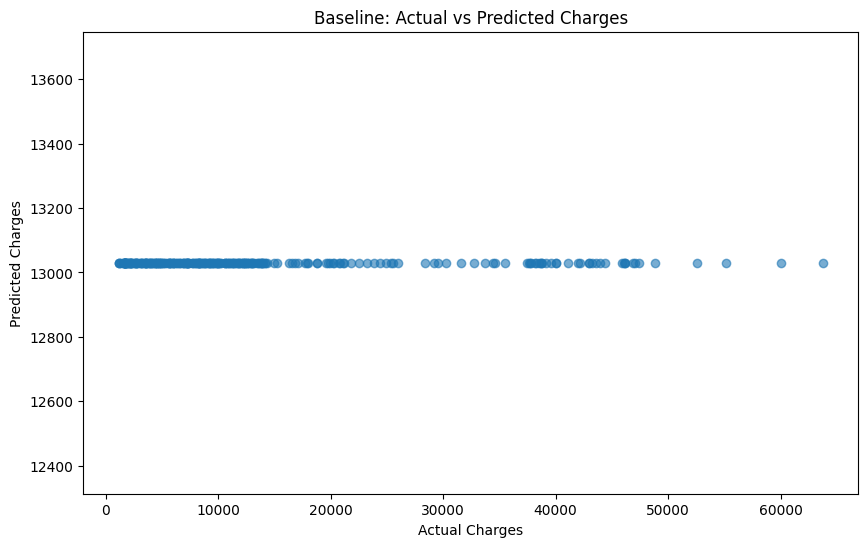

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred_baseline,
    alpha=0.6
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Baseline: Actual vs Predicted Charges")

plt.show()

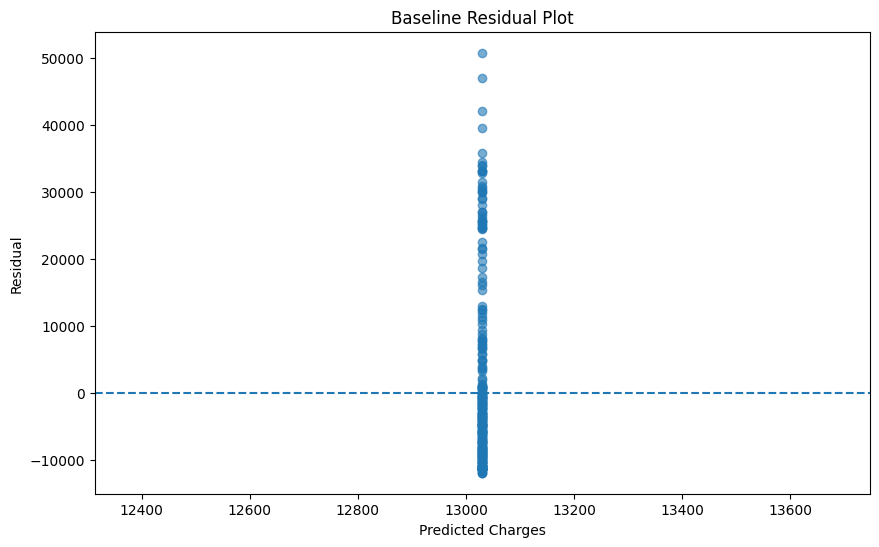

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_pred_baseline,
    baseline_residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Charges")
plt.ylabel("Residual")
plt.title("Baseline Residual Plot")

plt.show()

Interpretasi Baseline

Baseline menggunakan strategi mean, sehingga setiap observasi pada data
testing mendapatkan nilai prediksi yang sama, yaitu rata-rata `charges`
dari data training.

Model ini tidak menggunakan informasi seperti `age`, `bmi`, `smoker`,
`children`, `sex`, maupun `region`.

Nilai MAE dan RMSE baseline menunjukkan besarnya error yang harus
dikalahkan oleh model machine learning.

Nilai R² baseline digunakan sebagai titik pembanding untuk model
berikutnya.

Apabila model Linear Regression atau Random Forest menghasilkan MAE dan
RMSE yang lebih rendah serta R² yang lebih tinggi dibandingkan baseline,
maka model tersebut memberikan informasi prediktif tambahan dibandingkan
strategi sederhana menggunakan rata-rata target.

In [ ]:

results = pd.DataFrame({
    "Model": ["Baseline - Mean"],
    "MAE": [mae_baseline],
    "RMSE": [rmse_baseline],
    "R2": [r2_baseline]
})

results

,Model,MAE,RMSE,R2
0,Baseline - Mean,9861.80,13612.43,-0.01


# 8. Model Training

Pada tahap ini dilakukan training terhadap dua model regresi:

1. Linear Regression
2. Random Forest Regressor

Kedua model akan menggunakan preprocessing yang sama dan data training
yang sama agar perbandingan performa dilakukan secara adil.

Preprocessing ditempatkan di dalam Pipeline sehingga transformasi data
menjadi bagian dari proses training masing-masing model.

Random state ditetapkan untuk menjaga reproducibility.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [ ]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

print("Linear Regression pipeline berhasil dibuat.")

Linear Regression pipeline berhasil dibuat.


In [ ]:
linear_model.fit(
    X_train,
    y_train
)

print("Linear Regression berhasil dilatih.")

Linear Regression berhasil dilatih.


In [ ]:
y_pred_linear = linear_model.predict(X_test)

print("5 prediksi pertama Linear Regression:")
print(y_pred_linear[:5])

5 prediksi pertama Linear Regression:
[ 8143.69388412  5737.11568259 14369.31487618 31745.51363586
  8962.38665706]


In [ ]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest pipeline berhasil dibuat.")

Random Forest pipeline berhasil dibuat.


In [ ]:
random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest berhasil dilatih.")

Random Forest berhasil dilatih.


In [ ]:
y_pred_rf = random_forest_model.predict(X_test)

print("5 prediksi pertama Random Forest:")
print(y_pred_rf[:5])

5 prediksi pertama Random Forest:
[ 9303.9505234   9411.7621204  12428.340466   43039.01301107
  6729.0135522 ]


In [ ]:
print("Jumlah data testing :", len(X_test))
print("Prediksi Linear     :", len(y_pred_linear))
print("Prediksi RandomForest:", len(y_pred_rf))

Jumlah data testing : 268
Prediksi Linear     : 268
Prediksi RandomForest: 268


In [ ]:
prediction_comparison = pd.DataFrame({
    "Actual Charges": y_test.values,
    "Linear Regression": y_pred_linear,
    "Random Forest": y_pred_rf
})

prediction_comparison.head(10)

,Actual Charges,Linear Regression,Random Forest
0,8688.86,8143.69,9303.95
1,5708.87,5737.12,9411.76
2,11436.74,14369.31,12428.34
3,38746.36,31745.51,43039.01
4,4463.21,8962.39,6729.01
5,9304.70,13149.72,9890.22
6,38511.63,30446.76,38203.34
7,2150.47,1453.29,2295.30
8,7345.73,10633.02,10589.48
9,10264.44,11318.94,10767.08


In [ ]:
prediction_comparison.round(2).head(10)

,Actual Charges,Linear Regression,Random Forest
0,8688.86,8143.69,9303.95
1,5708.87,5737.12,9411.76
2,11436.74,14369.31,12428.34
3,38746.36,31745.51,43039.01
4,4463.21,8962.39,6729.01
5,9304.70,13149.72,9890.22
6,38511.63,30446.76,38203.34
7,2150.47,1453.29,2295.30
8,7345.73,10633.02,10589.48
9,10264.44,11318.94,10767.08


In [ ]:
r2_train_linear = linear_model.score(
    X_train,
    y_train
)

r2_train_rf = random_forest_model.score(
    X_train,
    y_train
)

print("Training R²")
print("----------------------")
print(f"Linear Regression : {r2_train_linear:.4f}")
print(f"Random Forest     : {r2_train_rf:.4f}")

Training R²
----------------------
Linear Regression : 0.7299
Random Forest     : 0.9752


Alasan Pemilihan Model

Linear Regression

Linear Regression digunakan sebagai model regresi linear yang relatif
sederhana dan mudah diinterpretasikan.

Model ini memberikan baseline machine learning yang dapat digunakan
untuk mengetahui seberapa baik hubungan linear dapat digunakan untuk
memprediksi `charges`.

 Random Forest Regressor

Random Forest digunakan sebagai model ensemble berbasis decision tree.

Model ini dipilih untuk melihat apakah pendekatan non-linear dan
ensemble dapat menangkap pola pada data yang tidak dapat ditangkap
secara optimal oleh model linear.

Kedua model dibandingkan menggunakan dataset training dan testing yang
sama.

In [ ]:
model_summary = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "Training Data": [
        len(X_train),
        len(X_train)
    ],
    "Testing Data": [
        len(X_test),
        len(X_test)
    ]
})

model_summary

,Model,Training Data,Testing Data
0,Linear Regression,1069,268
1,Random Forest,1069,268


In [ ]:
print("Linear Regression Pipeline:")
print(linear_model)

print("\nRandom Forest Pipeline:")
print(random_forest_model)

Linear Regression Pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', LinearRegression())])

Random Forest Pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                               

Dua model berhasil dilatih menggunakan data training yang sama, yaitu
Linear Regression dan Random Forest Regressor.

Kedua model menggunakan preprocessing yang sama melalui Pipeline.
Variabel numerik diproses menggunakan StandardScaler, sedangkan variabel
kategorikal diproses menggunakan One-Hot Encoding.

Setelah proses training, kedua model menghasilkan prediksi terhadap
data testing yang sama.

Perbandingan performa kedua model akan dilakukan pada tahap evaluasi
menggunakan MAE, RMSE, dan R².

# 9. Model Evaluation

Evaluasi dilakukan untuk membandingkan performa:

1. Baseline - Mean
2. Linear Regression
3. Random Forest Regressor

Seluruh model dievaluasi menggunakan data testing yang sama.

Metrik yang digunakan:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² (Coefficient of Determination)

MAE dan RMSE digunakan sebagai metrik error, sedangkan R² digunakan
sebagai metrik pendukung.

Model dengan MAE dan RMSE lebih rendah serta R² lebih tinggi memiliki
performa prediksi yang lebih baik pada data testing.

In [ ]:

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
mae_baseline = mean_absolute_error(
    y_test,
    y_pred_baseline
)

rmse_baseline = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_baseline
    )
)

r2_baseline = r2_score(
    y_test,
    y_pred_baseline
)

print("BASELINE")
print("-------------------------")
print(f"MAE  : {mae_baseline:.2f}")
print(f"RMSE : {rmse_baseline:.2f}")
print(f"R²   : {r2_baseline:.4f}")

BASELINE
-------------------------
MAE  : 9861.80
RMSE : 13612.43
R²   : -0.0084


In [ ]:
mae_linear = mean_absolute_error(
    y_test,
    y_pred_linear
)

rmse_linear = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_linear
    )
)

r2_linear = r2_score(
    y_test,
    y_pred_linear
)

print("LINEAR REGRESSION")
print("-------------------------")
print(f"MAE  : {mae_linear:.2f}")
print(f"RMSE : {rmse_linear:.2f}")
print(f"R²   : {r2_linear:.4f}")

LINEAR REGRESSION
-------------------------
MAE  : 4177.05
RMSE : 5956.34
R²   : 0.8069


In [ ]:
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("RANDOM FOREST")
print("-------------------------")
print(f"MAE  : {mae_rf:.2f}")
print(f"RMSE : {rmse_rf:.2f}")
print(f"R²   : {r2_rf:.4f}")

RANDOM FOREST
-------------------------
MAE  : 2644.65
RMSE : 4700.17
R²   : 0.8798


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Baseline - Mean",
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_baseline,
        mae_linear,
        mae_rf
    ],
    "RMSE": [
        rmse_baseline,
        rmse_linear,
        rmse_rf
    ],
    "R2": [
        r2_baseline,
        r2_linear,
        r2_rf
    ]
})

results. round(4)

,Model,MAE,RMSE,R2
0,Baseline - Mean,9861.80,13612.43,-0.01
1,Linear Regression,4177.05,5956.34,0.81
2,Random Forest,2644.65,4700.17,0.88


In [ ]:
results_by_mae = results.sort_values(
    by="MAE",
    ascending=True
)

results_by_mae

,Model,MAE,RMSE,R2
2,Random Forest,2644.65,4700.17,0.88
1,Linear Regression,4177.05,5956.34,0.81
0,Baseline - Mean,9861.80,13612.43,-0.01


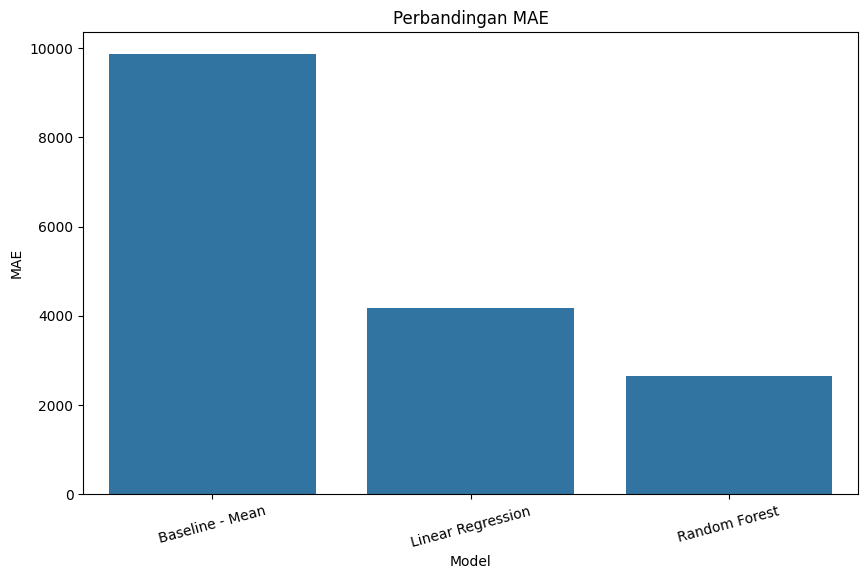

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results,
    x="Model",
    y="MAE"
)

plt.title("Perbandingan MAE")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=15)
plt.show()

MAE menunjukkan rata-rata besar kesalahan absolut antara nilai aktual
dan nilai prediksi.

Model dengan nilai MAE lebih rendah menghasilkan rata-rata kesalahan
prediksi yang lebih kecil pada data testing.

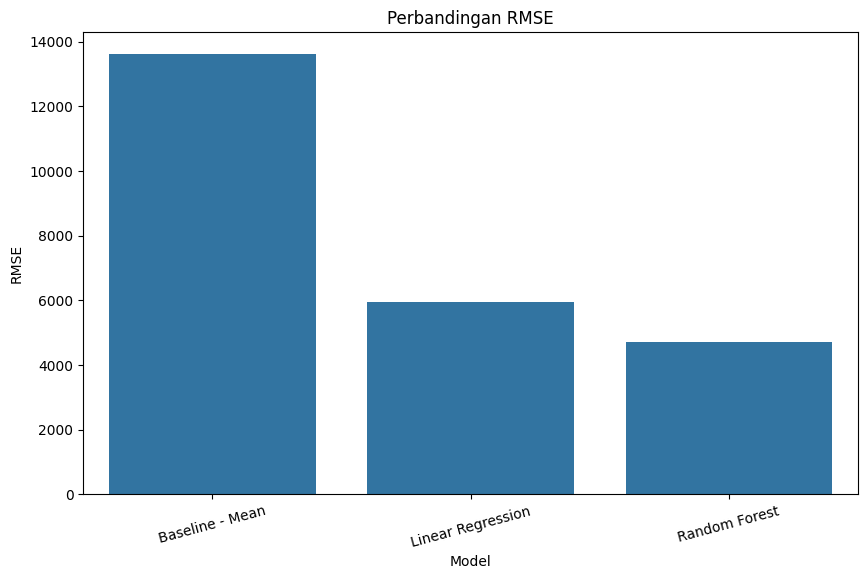

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results,
    x="Model",
    y="RMSE"
)

plt.title("Perbandingan RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.show()

RMSE memberikan penalti yang lebih besar terhadap kesalahan prediksi
yang besar karena error dikuadratkan sebelum dirata-ratakan.

Oleh karena itu, RMSE digunakan untuk membantu mengetahui apakah suatu
model menghasilkan kesalahan prediksi yang besar pada sebagian observasi.

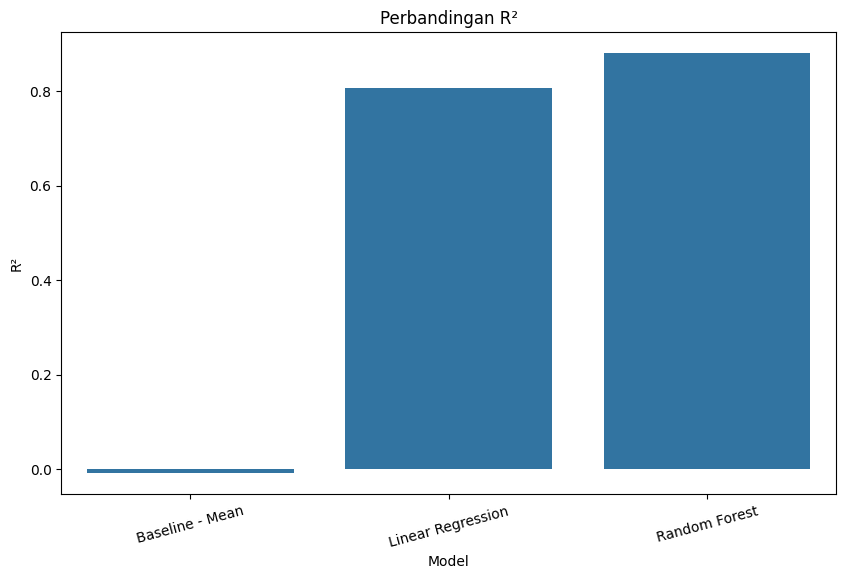

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results,
    x="Model",
    y="R2"
)

plt.title("Perbandingan R²")
plt.xlabel("Model")
plt.ylabel("R²")
plt.xticks(rotation=15)
plt.show()

R² menunjukkan proporsi variasi target yang dapat dijelaskan oleh model
dibandingkan dengan prediksi menggunakan rata-rata target.

Nilai R² yang lebih tinggi menunjukkan kemampuan model yang lebih baik
dalam menjelaskan variasi `charges` pada data testing.

R² dapat bernilai negatif apabila performa model lebih buruk daripada
model konstan yang menggunakan rata-rata target.

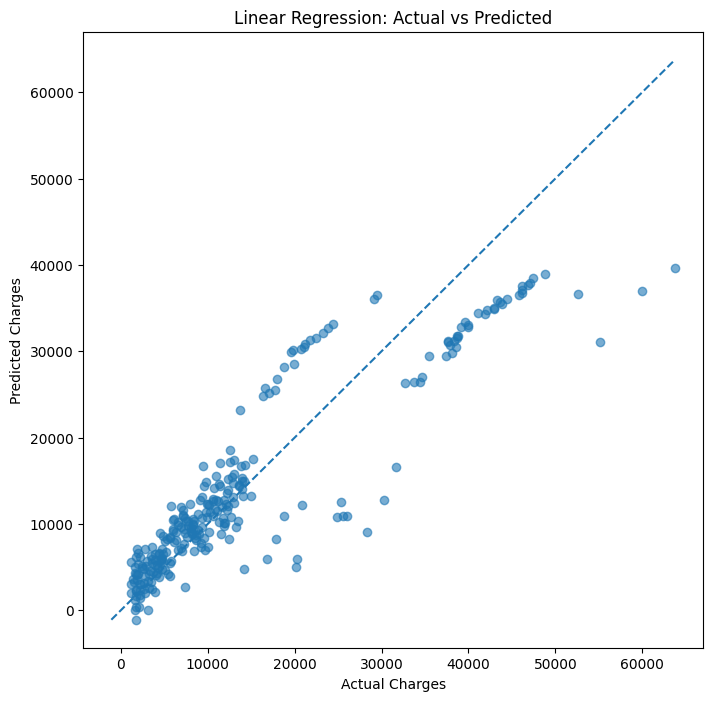

In [ ]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    y_pred_linear,
    alpha=0.6
)

min_value = min(
    y_test.min(),
    y_pred_linear.min()
)

max_value = max(
    y_test.max(),
    y_pred_linear.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

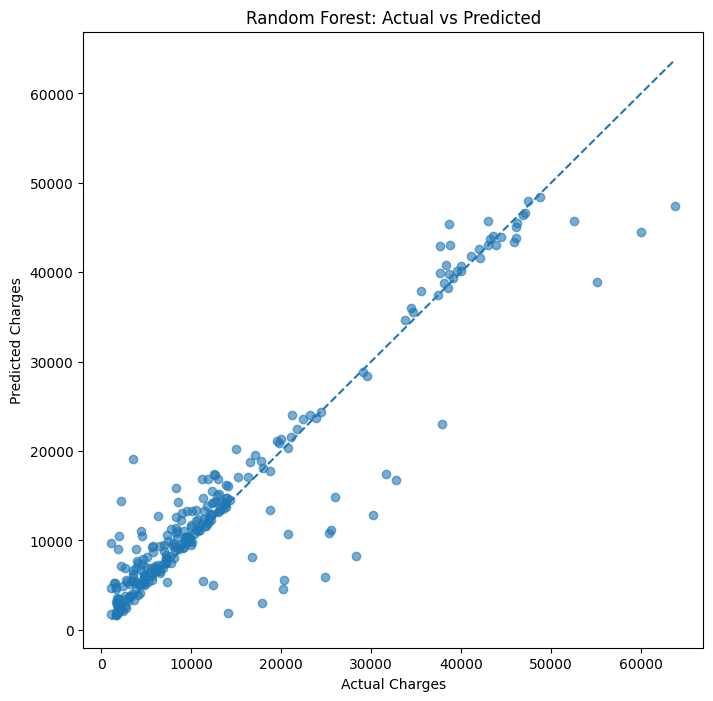

In [ ]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.6
)

min_value = min(
    y_test.min(),
    y_pred_rf.min()
)

max_value = max(
    y_test.max(),
    y_pred_rf.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

In [ ]:
residual_linear = y_test - y_pred_linear
residual_rf = y_test - y_pred_rf

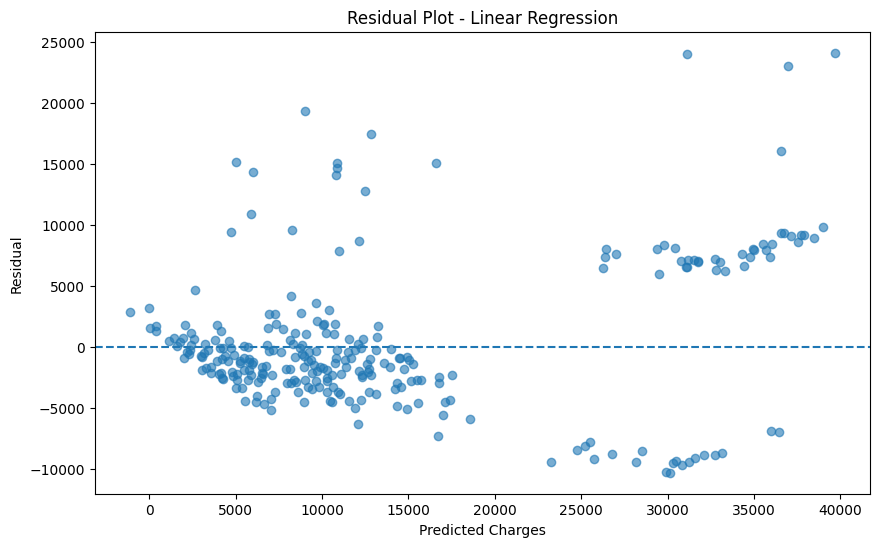

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_pred_linear,
    residual_linear,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Charges")
plt.ylabel("Residual")
plt.title("Residual Plot - Linear Regression")

plt.show()

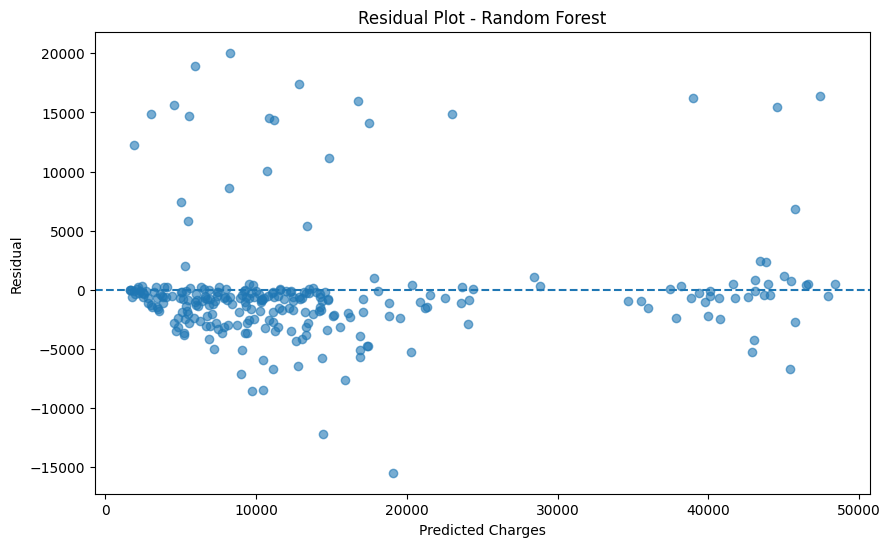

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_pred_rf,
    residual_rf,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Charges")
plt.ylabel("Residual")
plt.title("Residual Plot - Random Forest")

plt.show()

In [ ]:
residual_summary = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "Mean Residual": [
        residual_linear.mean(),
        residual_rf.mean()
    ],
    "MAE": [
        np.mean(np.abs(residual_linear)),
        np.mean(np.abs(residual_rf))
    ],
    "Max Absolute Error": [
        np.max(np.abs(residual_linear)),
        np.max(np.abs(residual_rf))
    ]
})

residual_summary.round(2)

,Model,Mean Residual,MAE,Max Absolute Error
0,Linear Regression,425.26,4177.05,24111.22
1,Random Forest,-336.53,2644.65,20055.05


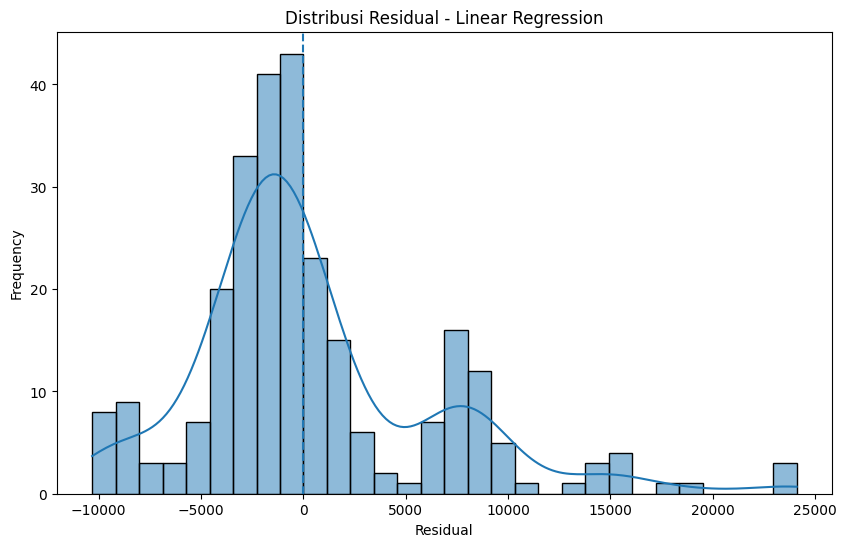

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    residual_linear,
    bins=30,
    kde=True
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.title("Distribusi Residual - Linear Regression")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

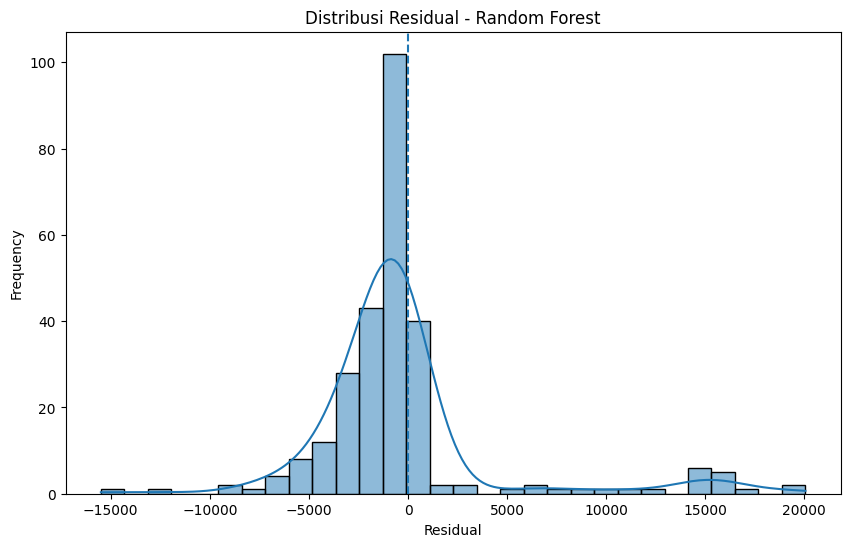

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    residual_rf,
    bins=30,
    kde=True
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.title("Distribusi Residual - Random Forest")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

In [ ]:
error_analysis = pd.DataFrame({
    "Actual": y_test.values,
    "Linear_Predicted": y_pred_linear,
    "RF_Predicted": y_pred_rf
})

error_analysis["Linear_Error"] = (
    error_analysis["Actual"]
    - error_analysis["Linear_Predicted"]
)

error_analysis["RF_Error"] = (
    error_analysis["Actual"]
    - error_analysis["RF_Predicted"]
)

error_analysis["Linear_Abs_Error"] = (
    error_analysis["Linear_Error"].abs()
)

error_analysis["RF_Abs_Error"] = (
    error_analysis["RF_Error"].abs()
)

error_analysis.sort_values(
    "RF_Abs_Error",
    ascending=False
).head(10).round(2)

,Actual,Linear_Predicted,RF_Predicted,Linear_Error,RF_Error,Linear_Abs_Error,RF_Abs_Error
124,28340.19,9028.58,8285.14,19311.61,20055.05,19311.61,20055.05
14,24915.05,10801.67,5946.63,14113.37,18968.41,14113.37,18968.41
79,30260.00,12811.72,12839.44,17448.28,17420.55,17448.28,17420.55
34,63770.43,39659.21,47384.47,24111.22,16385.95,24111.22,16385.95
24,55135.40,31107.77,38942.29,24027.64,16193.11,24027.64,16193.11
175,32734.19,26263.84,16745.88,6470.34,15988.31,6470.34,15988.31
197,20177.67,5028.42,4564.79,15149.25,15612.88,15149.25,15612.88
25,3579.83,5511.96,19078.59,-1932.13,-15498.76,1932.13,15498.76
254,60021.40,36988.22,44555.01,23033.18,15466.39,23033.18,15466.39
190,17878.90,8282.95,3004.84,9595.95,14874.06,9595.95,14874.06


In [ ]:
comparison = results.copy()

comparison["MAE_Improvement_vs_Baseline_%"] = (
    (mae_baseline - comparison["MAE"])
    / mae_baseline
) * 100

comparison["RMSE_Improvement_vs_Baseline_%"] = (
    (rmse_baseline - comparison["RMSE"])
    / rmse_baseline
) * 100

comparison.round(2)

,Model,MAE,RMSE,R2,MAE_Improvement_vs_Baseline_%,RMSE_Improvement_vs_Baseline_%
0,Baseline - Mean,9861.80,13612.43,-0.01,0.00,0.00
1,Linear Regression,4177.05,5956.34,0.81,57.64,56.24
2,Random Forest,2644.65,4700.17,0.88,73.18,65.47


MAE ditetapkan sebagai primary metric dalam pemilihan model.

Alasannya adalah MAE memiliki satuan yang sama dengan target `charges`
sehingga lebih mudah diinterpretasikan sebagai rata-rata besar kesalahan
prediksi biaya.

RMSE digunakan sebagai metrik pendukung untuk mengetahui pengaruh
kesalahan prediksi yang besar.

R² digunakan sebagai metrik tambahan untuk mengetahui seberapa besar
variasi target yang dapat dijelaskan oleh model.

Berdasarkan hasil testing, diperoleh perbandingan
performa antara baseline, Linear Regression, dan Random Forest.

Hasil RMSE dan R² digunakan sebagai informasi pendukung dalam evaluasi.
Analisis residual juga digunakan untuk melihat pola kesalahan dan
observasi dengan error yang relatif besar.

Pemilihan model akhir dilakukan berdasarkan keseluruhan bukti evaluasi,
bukan hanya satu metrik.

# 10. Feature Importance

Feature importance digunakan untuk mengetahui predictor mana yang
memberikan kontribusi relatif paling besar terhadap prediksi model
Random Forest.

Analisis ini bisa membantu menjawab pertanyaan :

"Variabel apa yang paling banyak digunakan oleh model dalam membuat
prediksi `charges`?"

Feature importance digunakan untuk interpretasi model dan bukan untuk
menyimpulkan hubungan sebab-akibat.

Pada penelitian ini, feature importance diambil dari Random Forest
Regressor.

In [ ]:
# Mengambil model Random Forest dari Pipeline

rf_model = random_forest_model.named_steps["model"]

print(rf_model)

RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)


In [ ]:
# Mengambil preprocessor yang sudah fitted
rf_preprocessor = random_forest_model.named_steps["preprocessor"]

# Mengambil nama fitur hasil preprocessing
feature_names_rf = rf_preprocessor.get_feature_names_out()

print("Jumlah fitur setelah preprocessing:")
print(len(feature_names_rf))

print("\nNama fitur:")
for feature in feature_names_rf:
    print(feature)

Jumlah fitur setelah preprocessing:
8

Nama fitur:
num__age
num__bmi
num__children
cat__sex_male
cat__smoker_yes
cat__region_northwest
cat__region_southeast
cat__region_southwest


In [ ]:

feature_importances = rf_model.feature_importances_

print("Jumlah feature importance:")
print(len(feature_importances))

Jumlah feature importance:
8


In [ ]:
len(feature_names_rf) == len(feature_importances)

True

In [ ]:

importance_df = pd.DataFrame({
    "Feature": feature_names_rf,
    "Importance": feature_importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

importance_df.round(4)

,Feature,Importance
0,cat__smoker_yes,0.60
1,num__bmi,0.22
2,num__age,0.14
3,num__children,0.02
4,cat__sex_male,0.01
5,cat__region_northwest,0.01
6,cat__region_southeast,0.01
7,cat__region_southwest,0.00


In [ ]:
importance_df["Rank"] = range(
    1,
    len(importance_df) + 1
)

importance_df = importance_df[
    ["Rank", "Feature", "Importance"]
]

importance_df.round(4)

,Rank,Feature,Importance
0,1,cat__smoker_yes,0.60
1,2,num__bmi,0.22
2,3,num__age,0.14
3,4,num__children,0.02
4,5,cat__sex_male,0.01
5,6,cat__region_northwest,0.01
6,7,cat__region_southeast,0.01
7,8,cat__region_southwest,0.00


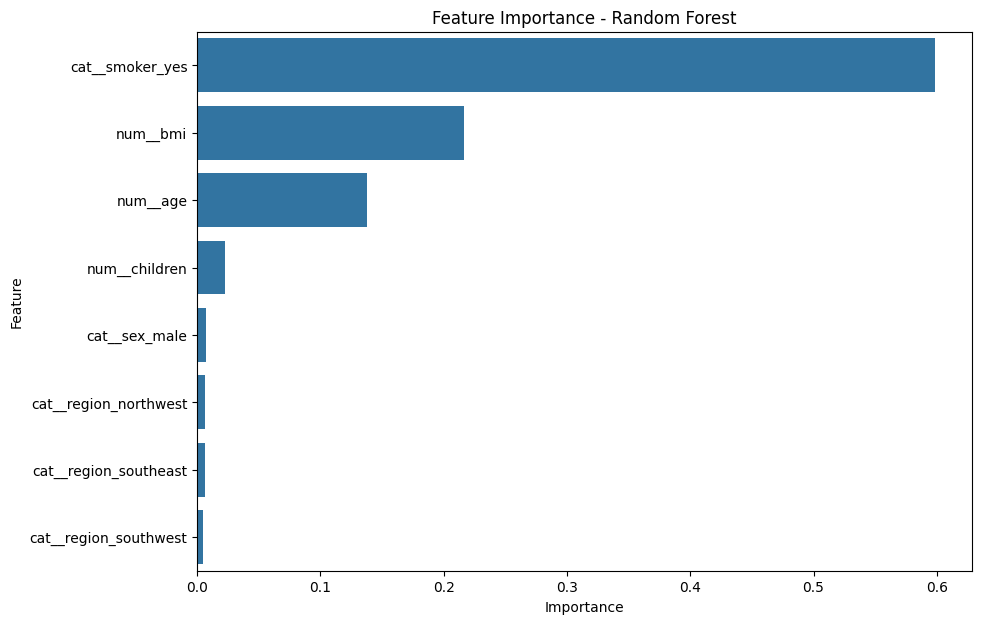

In [ ]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [ ]:
importance_display = importance_df.copy()

importance_display["Feature"] = (
    importance_display["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

importance_display.round(4)

,Rank,Feature,Importance
0,1,smoker_yes,0.60
1,2,bmi,0.22
2,3,age,0.14
3,4,children,0.02
4,5,sex_male,0.01
5,6,region_northwest,0.01
6,7,region_southeast,0.01
7,8,region_southwest,0.00


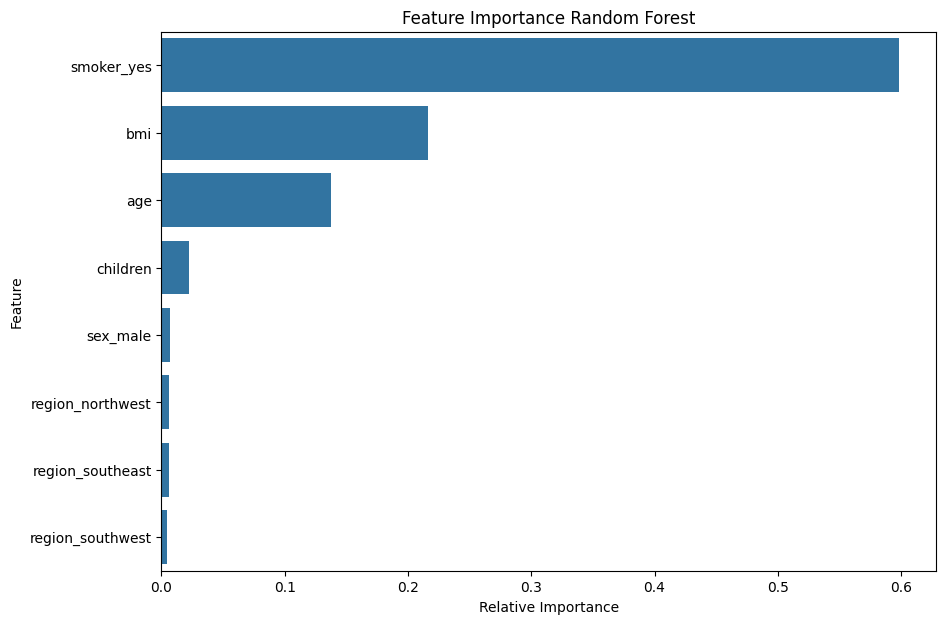

In [ ]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=importance_display,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance Random Forest")
plt.xlabel("Relative Importance")
plt.ylabel("Feature")

plt.show()

In [ ]:
total_importance = importance_df["Importance"].sum()

print(
    f"Total feature importance: {total_importance:.4f}"
)

Total feature importance: 1.0000


In [ ]:
importance_display["Importance_Percent"] = (
    importance_display["Importance"] * 100
)

importance_display.round(2)

,Rank,Feature,Importance,Importance_Percent
0,1,smoker_yes,0.60,59.87
1,2,bmi,0.22,21.63
2,3,age,0.14,13.79
3,4,children,0.02,2.27
4,5,sex_male,0.01,0.70
5,6,region_northwest,0.01,0.65
6,7,region_southeast,0.01,0.63
7,8,region_southwest,0.00,0.45


In [ ]:
grouped_importance = importance_display.copy()

def get_original_feature(feature):
    if feature.startswith("age"):
        return "age"
    elif feature.startswith("bmi"):
        return "bmi"
    elif feature.startswith("children"):
        return "children"
    elif feature.startswith("sex"):
        return "sex"
    elif feature.startswith("smoker"):
        return "smoker"
    elif feature.startswith("region"):
        return "region"
    else:
        return feature

grouped_importance["Original_Feature"] = (
    grouped_importance["Feature"]
    .apply(get_original_feature)
)

grouped_importance

,Rank,Feature,Importance,Importance_Percent,Original_Feature
0,1,smoker_yes,0.60,59.87,smoker
1,2,bmi,0.22,21.63,bmi
2,3,age,0.14,13.79,age
3,4,children,0.02,2.27,children
4,5,sex_male,0.01,0.70,sex
5,6,region_northwest,0.01,0.65,region
6,7,region_southeast,0.01,0.63,region
7,8,region_southwest,0.00,0.45,region


In [ ]:

original_feature_importance = (
    grouped_importance
    .groupby("Original_Feature")["Importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

original_feature_importance["Importance_Percent"] = (
    original_feature_importance["Importance"] * 100
)

original_feature_importance.round(2)

,Original_Feature,Importance,Importance_Percent
0,smoker,0.60,59.87
1,bmi,0.22,21.63
2,age,0.14,13.79
3,children,0.02,2.27
4,region,0.02,1.73
5,sex,0.01,0.70


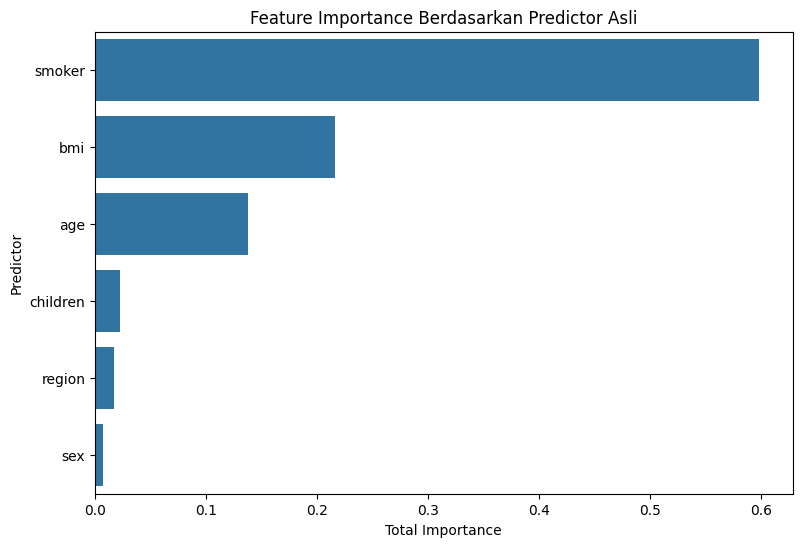

In [ ]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=original_feature_importance,
    x="Importance",
    y="Original_Feature"
)

plt.title("Feature Importance Berdasarkan Predictor Asli")
plt.xlabel("Total Importance")
plt.ylabel("Predictor")

plt.show()

Feature importance menunjukkan kontribusi relatif setiap predictor
terhadap prediksi yang dibuat oleh Random Forest.

Berdasarkan hasil model, predictor dengan importance paling tinggi
adalah `Smoker`, sedangkan predictor dengan
importance paling rendah adalah `sex`.

Hasil tersebut menunjukkan bahwa Random Forest lebih banyak menggunakan
informasi dari predictor dengan nilai importance yang lebih tinggi ketika
membangun prediksi.

Feature importance merupakan ukuran kontribusi prediktif dalam model dan
tidak dapat diinterpretasikan sebagai hubungan sebab-akibat.

In [ ]:
from sklearn.inspection import permutation_importance
perm_importance = permutation_importance(
    random_forest_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

In [ ]:
permutation_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_Mean": perm_importance.importances_mean,
    "Importance_STD": perm_importance.importances_std
})

permutation_df = permutation_df.sort_values(
    by="Importance_Mean",
    ascending=False
).reset_index(drop=True)

permutation_df

,Feature,Importance_Mean,Importance_STD
0,smoker,7765.41,377.60
1,age,2764.82,192.29
2,bmi,1955.07,215.55
3,children,309.59,53.46
4,region,134.90,49.40
5,sex,-26.66,31.43


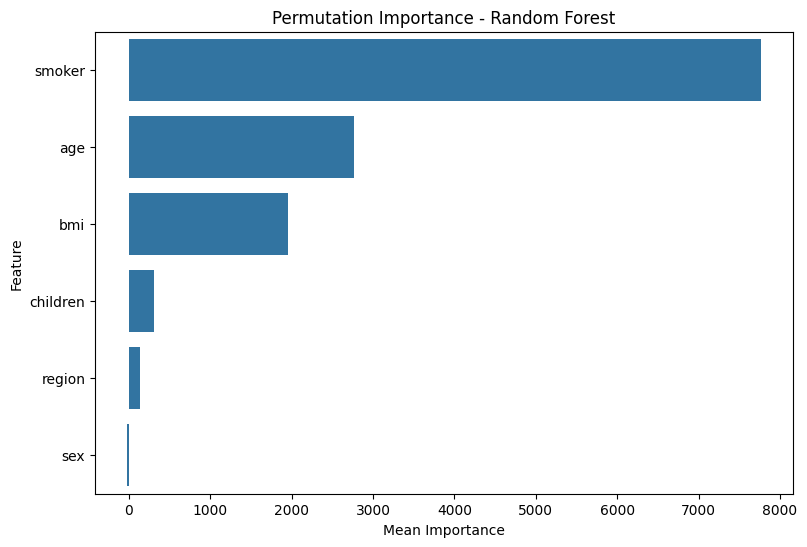

In [ ]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=permutation_df,
    x="Importance_Mean",
    y="Feature"
)

plt.title("Permutation Importance - Random Forest")
plt.xlabel("Mean Importance")
plt.ylabel("Feature")

plt.show()


Interpretasi Permutation Importance

Permutation importance mengukur perubahan performa model ketika nilai
suatu fitur diacak pada data testing.

Jika pengacakan suatu fitur menyebabkan performa model menurun lebih
besar, fitur tersebut memiliki kontribusi prediktif yang lebih besar
terhadap performa model pada data testing.

In [ ]:
importance_comparison = pd.DataFrame({
    "Feature": feature_names_rf,
    "Impurity_Importance": feature_importances
})

importance_comparison = importance_comparison.sort_values(
    by="Impurity_Importance",
    ascending=False
)

importance_comparison.round(4)

,Feature,Impurity_Importance
4,cat__smoker_yes,0.60
1,num__bmi,0.22
0,num__age,0.14
2,num__children,0.02
3,cat__sex_male,0.01
5,cat__region_northwest,0.01
6,cat__region_southeast,0.01
7,cat__region_southwest,0.00


Feature importance digunakan untuk memahami predictor yang paling banyak
berkontribusi terhadap prediksi Random Forest.

Analisis dilakukan menggunakan `feature_importances_` dari Random Forest
dan dilengkapi dengan permutation importance sebagai analisis tambahan.

Hasil feature importance digunakan untuk interpretasi model dan untuk
memahami pola prediktif dalam dataset.

Feature importance tidak diinterpretasikan sebagai hubungan sebab-akibat.
Nilai importance menunjukkan kontribusi relatif fitur terhadap prediksi
model pada dataset yang digunakan.

## 11. Conclusion & Recommendations

Pada tahap akhir, performa seluruh model dibandingkan menggunakan MAE sebagai metrik utama, dengan RMSE dan R² sebagai metrik pendukung.

In [ ]:

model_comparison = results.sort_values(
    by="MAE",
    ascending=True
).reset_index(drop=True)

print("Perbandingan akhir model:")
display(model_comparison)

Perbandingan akhir model:


,Model,MAE,RMSE,R2
0,Random Forest,2644.65,4700.17,0.88
1,Linear Regression,4177.05,5956.34,0.81
2,Baseline - Mean,9861.80,13612.43,-0.01


In [ ]:
selected_model_name = model_comparison.loc[0, "Model"]

selected_mae = model_comparison.loc[0, "MAE"]
selected_rmse = model_comparison.loc[0, "RMSE"]
selected_r2 = model_comparison.loc[0, "R2"]

print("Model terpilih :", selected_model_name)
print(f"MAE           : {selected_mae:,.2f}")
print(f"RMSE          : {selected_rmse:,.2f}")
print(f"R²            : {selected_r2:.4f}")

Model terpilih : Random Forest
MAE           : 2,644.65
RMSE          : 4,700.17
R²            : 0.8798



Model terpilih ditentukan berdasarkan nilai MAE pada data pengujian. MAE digunakan sebagai metrik utama karena menunjukkan rata-rata besar kesalahan prediksi dalam satuan biaya asuransi.

RMSE digunakan sebagai metrik pendukung untuk melihat besarnya kesalahan yang lebih sensitif terhadap error yang besar, sedangkan R² digunakan untuk memberikan informasi tambahan mengenai kemampuan model dalam menjelaskan variasi nilai target.

Pemilihan model tidak hanya mempertimbangkan satu angka. Hasil MAE dibandingkan dengan RMSE, R², baseline, serta pola residual yang telah dianalisis pada tahap evaluasi.

In [ ]:
baseline_mae = results.loc[
    results["Model"] == "Baseline - Mean",
    "MAE"
].iloc[0]

model_comparison["MAE_Improvement_vs_Baseline_%"] = (
    (baseline_mae - model_comparison["MAE"])
    / baseline_mae
) * 100

display(model_comparison)

,Model,MAE,RMSE,R2,MAE_Improvement_vs_Baseline_%
0,Random Forest,2644.65,4700.17,0.88,73.18
1,Linear Regression,4177.05,5956.34,0.81,57.64
2,Baseline - Mean,9861.80,13612.43,-0.01,0.00


In [135]:
y_pred_linear
y_pred_rf

array([ 9303.9505234 ,  9411.7621204 , 12428.340466  , 43039.01301107,
        6729.0135522 ,  9890.21609783, 38203.34311503,  2295.30355207,
       10589.48121893, 10767.0762715 , 14351.1439748 , 24352.21637727,
       42899.3090984 , 15172.87501733,  5946.63201623,  9683.36938267,
       10447.81714147, 39797.34738913,  5892.47834353,  5318.22023787,
        9015.75077153, 20342.61127393, 10193.65676727, 21556.5802522 ,
       38942.29135567, 19078.5921902 , 43077.12587903, 45767.09431   ,
       10500.33104447, 12443.33566937,  4119.15781083,  9174.1994222 ,
        3046.8292924 , 14170.23285147, 47384.47326067,  9960.55436223,
        7886.62017263,  5586.5716536 , 24062.9217341 ,  8907.29343563,
        2407.22459533, 20852.216696  , 41642.7651866 ,  9506.84958513,
        9266.2863924 ,  3814.6056185 ,  2545.40019683,  7964.63972123,
        7454.81503847, 12788.29489957,  5157.03948683,  8713.55934513,
       22494.48875347,  5235.65428173,  7885.2701318 , 11242.8487682 ,
      

In [136]:
if selected_model_name == "Linear Regression":
    y_pred_selected = y_pred_linear
elif selected_model_name == "Random Forest":
    y_pred_selected = y_pred_rf
else:
    y_pred_selected = y_pred_baseline

residual_selected = y_test - y_pred_selected

error_analysis_selected = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_selected,
    "Residual": residual_selected.values,
    "Absolute_Error": np.abs(residual_selected.values)
})

display(error_analysis_selected.head(10))

,Actual,Predicted,Residual,Absolute_Error
0,8688.86,9303.95,-615.09,615.09
1,5708.87,9411.76,-3702.90,3702.90
2,11436.74,12428.34,-991.60,991.60
3,38746.36,43039.01,-4292.66,4292.66
4,4463.21,6729.01,-2265.81,2265.81
5,9304.70,9890.22,-585.51,585.51
6,38511.63,38203.34,308.29,308.29
7,2150.47,2295.30,-144.83,144.83
8,7345.73,10589.48,-3243.75,3243.75
9,10264.44,10767.08,-502.63,502.63


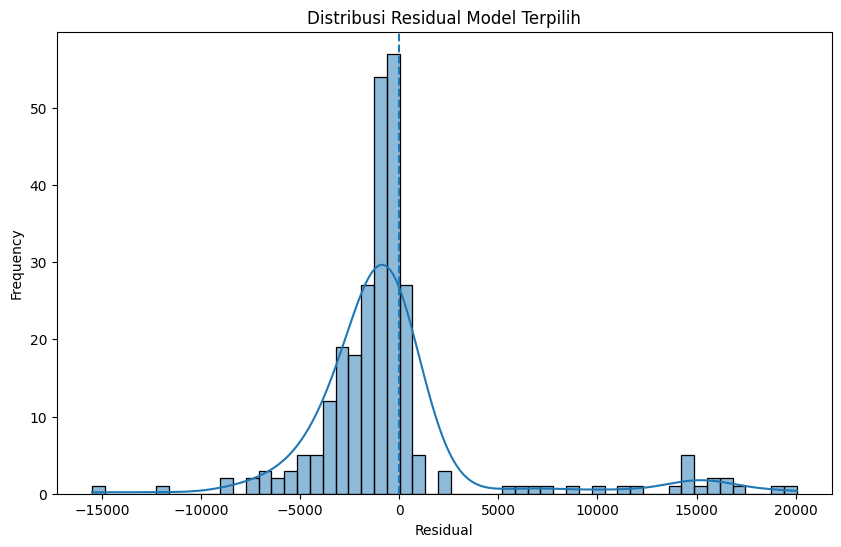

In [137]:
plt.figure(figsize=(10, 6))

sns.histplot(
    residual_selected,
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Distribusi Residual Model Terpilih")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

Residual dihitung sebagai selisih antara nilai aktual dan nilai prediksi:

Residual = Actual - Predicted

Residual digunakan untuk melihat pola kesalahan prediksi model. Distribusi residual yang relatif terpusat di sekitar nol menunjukkan bahwa model tidak secara konsisten menghasilkan prediksi yang terlalu tinggi atau terlalu rendah.

Namun, residual yang besar tetap dapat muncul pada beberapa observasi. Observasi tersebut perlu diperhatikan karena dapat menunjukkan kasus yang sulit diprediksi oleh model atau karakteristik data yang belum sepenuhnya direpresentasikan oleh predictor yang tersedia.

In [138]:
top_errors = (
    error_analysis_selected
    .sort_values(
        by="Absolute_Error",
        ascending=False
    )
    .head(10)
)

display(top_errors)

,Actual,Predicted,Residual,Absolute_Error
124,28340.19,8285.14,20055.05,20055.05
14,24915.05,5946.63,18968.41,18968.41
79,30260.00,12839.44,17420.55,17420.55
34,63770.43,47384.47,16385.95,16385.95
24,55135.40,38942.29,16193.11,16193.11
175,32734.19,16745.88,15988.31,15988.31
197,20177.67,4564.79,15612.88,15612.88
25,3579.83,19078.59,-15498.76,15498.76
254,60021.40,44555.01,15466.39,15466.39
190,17878.90,3004.84,14874.06,14874.06


Sepuluh observasi dengan absolute error terbesar diperiksa untuk mengetahui apakah terdapat pola tertentu pada kasus yang sulit diprediksi.

Penelitian ini membangun model regresi untuk memprediksi biaya asuransi kesehatan (`charges`) berdasarkan karakteristik peserta, yaitu `age`, `sex`, `bmi`, `children`, `smoker`, dan `region`.

Dataset terdiri dari 1.338 observasi awal dan 7 variabel. Setelah dilakukan pemeriksaan kualitas data, ditemukan satu baris duplikat yang kemudian dihapus sehingga dataset akhir yang digunakan terdiri dari 1.337 observasi.

Tahap data preparation dilakukan dengan memisahkan predictor dan target, membagi data menjadi training dan testing dengan proporsi 80:20, melakukan standardisasi pada variabel numerik, serta melakukan One-Hot Encoding pada variabel kategorikal. Preprocessing diterapkan melalui pipeline sehingga proses transformasi dapat dilakukan secara konsisten dan mengurangi risiko data leakage.

Tiga pendekatan dibandingkan, yaitu Mean Baseline, Linear Regression, dan Random Forest Regressor. Evaluasi dilakukan menggunakan MAE sebagai metrik utama, sedangkan RMSE dan R² digunakan sebagai metrik pendukung.

Berdasarkan hasil pengujian pada data testing, model yang memiliki nilai MAE terendah dipilih sebagai model utama. Hasil aktual dari perbandingan model digunakan sebagai dasar pemilihan, bukan performa training saja.

Analisis residual kemudian digunakan untuk melihat pola kesalahan model dan mengidentifikasi observasi dengan error yang relatif besar.

Feature importance dari Random Forest digunakan untuk memahami predictor mana yang memiliki kontribusi prediktif paling besar terhadap hasil model. Hasil tersebut tidak diinterpretasikan sebagai hubungan sebab-akibat.

Secara keseluruhan, model yang dikembangkan dapat digunakan sebagai pendekatan prediktif untuk membantu memperkirakan biaya asuransi berdasarkan karakteristik yang tersedia dalam dataset.

In [139]:
final_summary = pd.DataFrame({
    "Item": [
        "Dataset awal",
        "Dataset setelah duplicate removal",
        "Jumlah predictor",
        "Target",
        "Train samples",
        "Test samples",
        "Primary metric",
        "Selected model",
        "MAE",
        "RMSE",
        "R²"
    ],
    "Value": [
        len(df),
        len(df_clean),
        len(features),
        target,
        len(X_train),
        len(X_test),
        "MAE",
        selected_model_name,
        selected_mae,
        selected_rmse,
        selected_r2
    ]
})

display(final_summary)

,Item,Value
0,Dataset awal,1338
1,Dataset setelah duplicate removal,1337
2,Jumlah predictor,6
3,Target,charges
4,Train samples,1069
5,Test samples,268
6,Primary metric,MAE
7,Selected model,Random Forest
8,MAE,2644.65
9,RMSE,4700.17
